In [ ]:
import pandas as pd

# Load the dataset 
df = pd.read_csv("Pokemon.csv")

# Extract column headers
print("Column Headers:", df.columns.tolist())
# Display the first few rows of the dataset
print("\nFirst few rows:\n", df.head())

# Check for missing values
print("\nMissing Values:\n", df.isnull().sum())


In [20]:
import pandas as pd

# Load dataset 
df = pd.read_csv("Pokemon.csv")

# Relevant stat columns for comparison
stat_columns = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]

# Function to find the most similar Pokémon by stats (within same Type 1 and Generation)
def find_closest_type2(row, df):
    if pd.notna(row["Type 2"]) or row["Legendary"]:  # Keep existing Type 2 & don't fill for Legendary
        return row["Type 2"]
    
    # Filter Pokémon with the same Type 1 and same Generation
    candidates = df[(df["Type 1"] == row["Type 1"]) & 
                    (df["Generation"] == row["Generation"]) & 
                    (df["Type 2"].notna())]  # Only those with known Type 2
    
    if candidates.empty:
        # Fallback: If no candidates, use most common Type 2 for the same Type 1
        most_common_type2 = df[df["Type 1"] == row["Type 1"]]["Type 2"].mode()
        if not most_common_type2.empty:
            return most_common_type2[0]
        return None  # If still no match, return None
    
    # Compute the sum of absolute differences (Manhattan distance)
    candidates["similarity"] = candidates[stat_columns].apply(
        lambda x: sum(abs(x - row[stat_columns])), axis=1
    )
    
    # Find the closest match 
    closest_index = candidates["similarity"].idxmin()
    return df.loc[closest_index, "Type 2"]

# Apply the function to fill missing Type 2 values for all Pokémon (Legendary and non-Legendary)
df["Type 2"] = df.apply(lambda row: find_closest_type2(row, df), axis=1)

# Check for missing values after filling
print("\nMissing Values After Filling:\n", df.isnull().sum())

# Save the updated dataset 
output_file_path = r"C:\Users\DELL\Downloads\pokemon_data_filled_by_stats.csv"
df.to_csv(output_file_path, index=False)

print(f"\nUpdated dataset saved as '{output_file_path}'")


Missing Values After Filling:
 #              0
Name           0
Type 1         0
Type 2        25
Total          0
HP             0
Attack         0
Defense        0
Sp. Atk        0
Sp. Def        0
Speed          0
Generation     0
Legendary      0
dtype: int64

Updated dataset saved as 'C:\Users\DELL\Downloads\pokemon_data_filled_by_stats.csv'


In [3]:
import pandas as pd

df = pd.read_csv("C:\\Users\\DELL\\Downloads\\pokemon_data_filled_by_stats.csv")

# Relevant numerical columns
numerical_features = ['Total', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Generation']

# 1. Get basic descriptive statistics
descriptive_stats = df[numerical_features].describe()

# 2. Variance
variance = df[numerical_features].var()

# 3. Coefficient of Variation (CV) - 
cv = (df[numerical_features].std() / df[numerical_features].mean()) * 100

# 4. Range (Max - Min)
range_values = df[numerical_features].max() - df[numerical_features].min()

# 5. Interquartile Range (IQR)
IQR = df[numerical_features].quantile(0.75) - df[numerical_features].quantile(0.25)

# 6. Skewness and Kurtosis
skewness = df[numerical_features].skew()
kurtosis = df[numerical_features].kurt()

# 7. Correlation matrix (Pearson)
correlation_matrix = df[numerical_features].corr()

# 8. Outlier detection using IQR (Identifying outliers in 'Total' column as an example)
Q1 = df['Total'].quantile(0.25)
Q3 = df['Total'].quantile(0.75)
IQR_Total = Q3 - Q1
outliers = df[(df['Total'] < (Q1 - 1.5 * IQR_Total)) | (df['Total'] > (Q3 + 1.5 * IQR_Total))]

#  results
print("Descriptive Statistics for Numerical Features:")
print(descriptive_stats)

print("\nVariance:")
print(variance)

print("\nCoefficient of Variation (%):")
print(cv)

print("\nRange (Max - Min):")
print(range_values)

print("\nInterquartile Range (IQR):")
print(IQR)

print("\nSkewness:")
print(skewness)

print("\nKurtosis:")
print(kurtosis)

print("\nCorrelation Matrix:")
print(correlation_matrix)

print("\nOutliers based on IQR (in 'Total' column):")
print(outliers)


Descriptive Statistics for Numerical Features:
           Total          HP      Attack     Defense     Sp. Atk     Sp. Def  \
count  800.00000  800.000000  800.000000  800.000000  800.000000  800.000000   
mean   435.10250   69.258750   79.001250   73.842500   72.820000   71.902500   
std    119.96304   25.534669   32.457366   31.183501   32.722294   27.828916   
min    180.00000    1.000000    5.000000    5.000000   10.000000   20.000000   
25%    330.00000   50.000000   55.000000   50.000000   49.750000   50.000000   
50%    450.00000   65.000000   75.000000   70.000000   65.000000   70.000000   
75%    515.00000   80.000000  100.000000   90.000000   95.000000   90.000000   
max    780.00000  255.000000  190.000000  230.000000  194.000000  230.000000   

            Speed  Generation  
count  800.000000   800.00000  
mean    68.277500     3.32375  
std     29.060474     1.66129  
min      5.000000     1.00000  
25%     45.000000     2.00000  
50%     65.000000     3.00000  
75%     

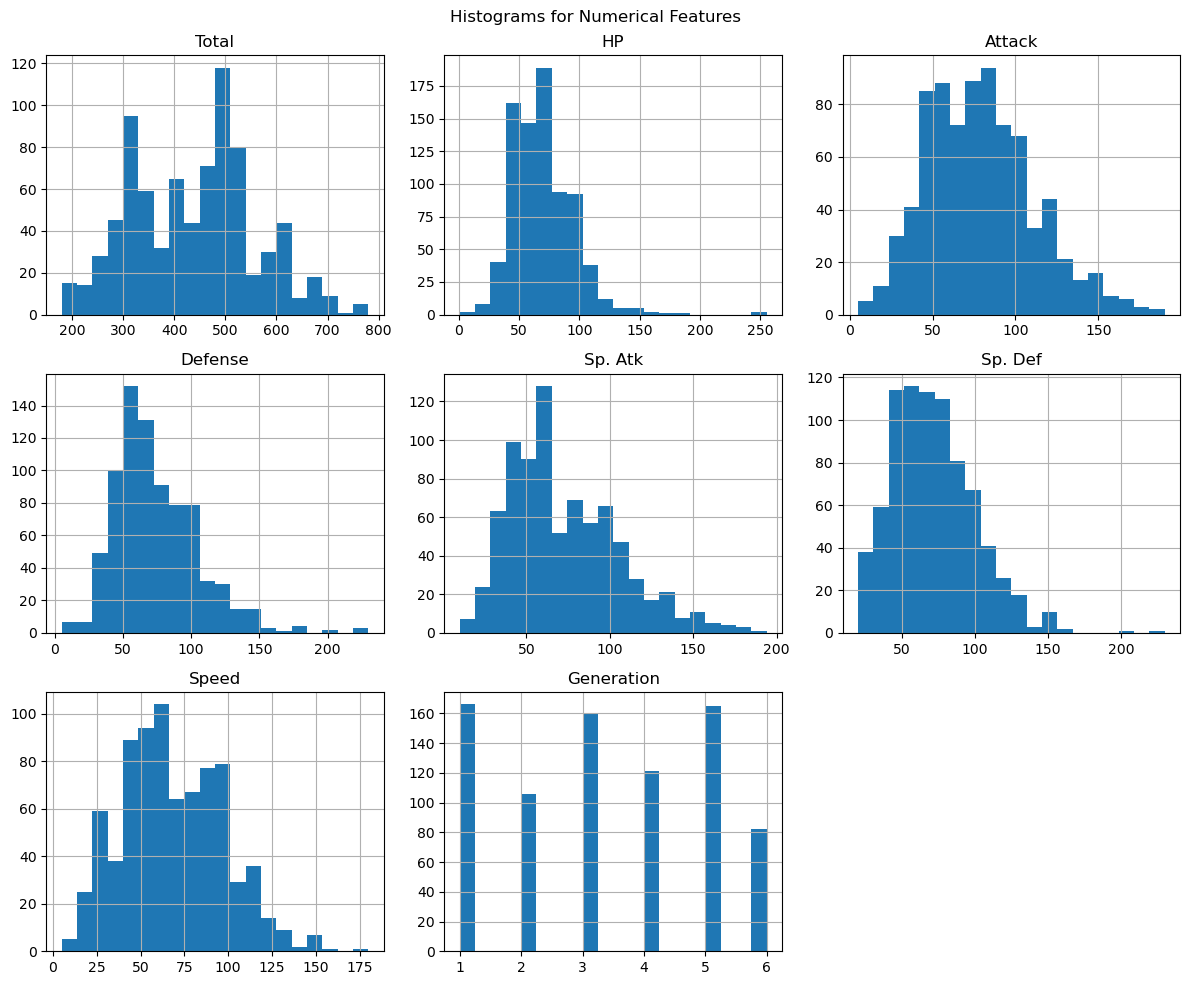

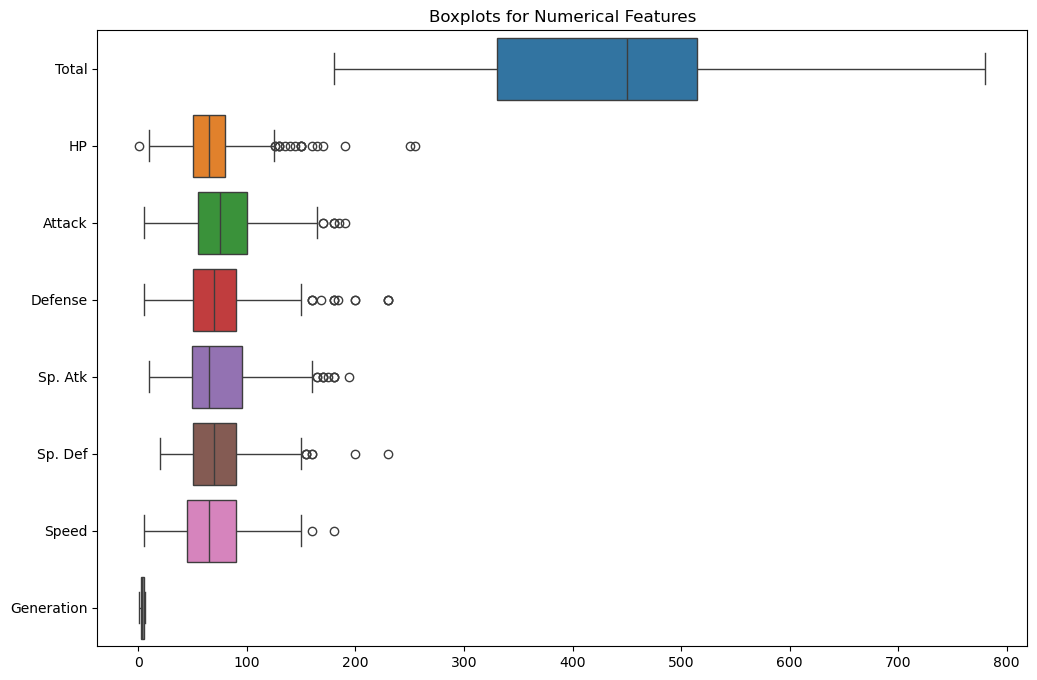

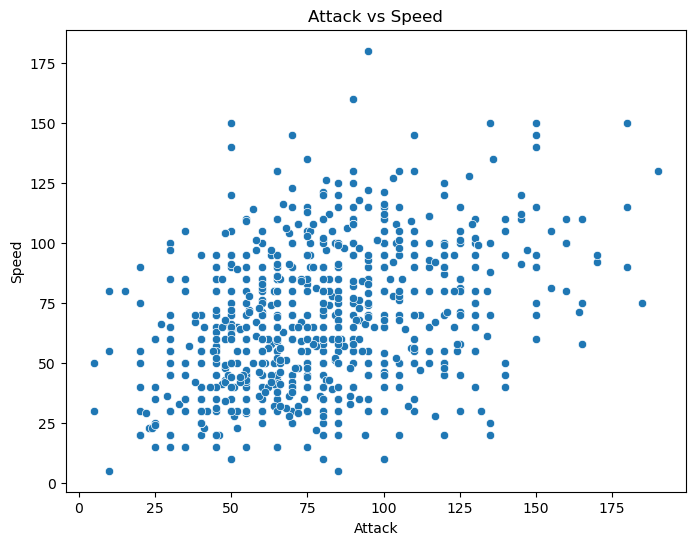

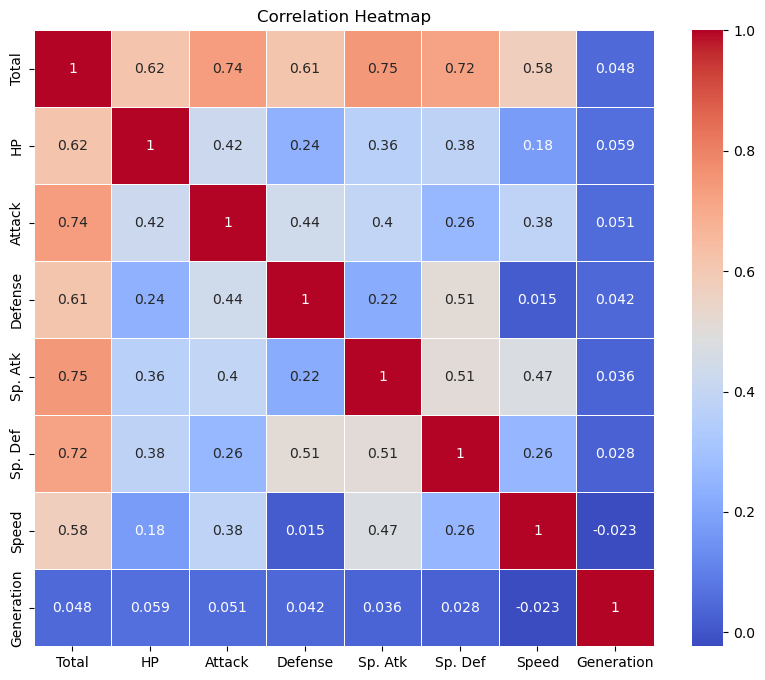

Mean values:
Total         435.10250
HP             69.25875
Attack         79.00125
Defense        73.84250
Sp. Atk        72.82000
Sp. Def        71.90250
Speed          68.27750
Generation      3.32375
dtype: float64

Median values:
Total         450.0
HP             65.0
Attack         75.0
Defense        70.0
Sp. Atk        65.0
Sp. Def        70.0
Speed          65.0
Generation      3.0
dtype: float64

Mode values:
Total         600
HP             60
Attack        100
Defense        70
Sp. Atk        60
Sp. Def        80
Speed          50
Generation      1
Name: 0, dtype: int64

Variance values:
Total         14391.130907
HP              652.019323
Attack         1053.480599
Defense         972.410707
Sp. Atk        1070.748536
Sp. Def         774.448554
Speed           844.511133
Generation        2.759886
dtype: float64

Standard Deviation values:
Total         119.963040
HP             25.534669
Attack         32.457366
Defense        31.183501
Sp. Atk        32.722294
Sp. Def

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:\\Users\\DELL\\Downloads\\pokemon_data_filled_by_stats.csv")

# Relevant numerical columns
numerical_features = ['Total', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Generation']

# 1. Calculate Mean, Median, Mode, Variance, and Standard Deviation
mean_values = df[numerical_features].mean()
median_values = df[numerical_features].median()
mode_values = df[numerical_features].mode().iloc[0]  # Mode may have more than one value
variance_values = df[numerical_features].var()
std_dev_values = df[numerical_features].std()

# 2. Visualizing the results
# 2.1 Histograms for numerical features
df[numerical_features].hist(figsize=(12, 10), bins=20)
plt.suptitle('Histograms for Numerical Features')
plt.tight_layout()
plt.show()

# 2.2 Boxplots for numerical features
plt.figure(figsize=(12, 8))
sns.boxplot(data=df[numerical_features], orient='h')
plt.title('Boxplots for Numerical Features')
plt.show()

# 2.3 Scatter Plot for Attack vs Speed
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Attack', y='Speed', data=df)
plt.title('Attack vs Speed')
plt.xlabel('Attack')
plt.ylabel('Speed')
plt.show()

# 2.4 Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_features].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# 3. Print the calculated values
print("Mean values:")
print(mean_values)

print("\nMedian values:")
print(median_values)

print("\nMode values:")
print(mode_values)

print("\nVariance values:")
print(variance_values)

print("\nStandard Deviation values:")
print(std_dev_values)


Average Stats by Type 1:
               Total         HP      Attack     Defense    Sp. Atk    Sp. Def  \
Type 1                                                                          
Dragon    550.531250  83.312500  112.125000   86.375000  96.843750  88.843750   
Steel     487.703704  65.222222   92.703704  126.370370  67.518519  80.629630   
Flying    485.000000  70.750000   78.750000   66.250000  94.250000  72.500000   
Psychic   475.947368  70.631579   71.456140   67.684211  98.403509  86.280702   
Fire      458.076923  69.903846   84.769231   67.769231  88.980769  72.211538   
Rock      453.750000  65.363636   92.863636  100.795455  63.340909  75.477273   
Dark      445.741935  66.806452   88.387097   70.225806  74.645161  69.516129   
Electric  443.409091  59.795455   69.090909   66.295455  90.022727  73.704545   
Ghost     439.562500  64.437500   73.781250   81.187500  79.343750  76.468750   
Ground    437.500000  73.781250   95.750000   84.843750  56.468750  62.750000   
Ice

C:\Users\DELL\AppData\Local\Temp\ipykernel_3516\155499435.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type1_avg_stats.index, y=type1_avg_stats["Total"], palette="viridis")


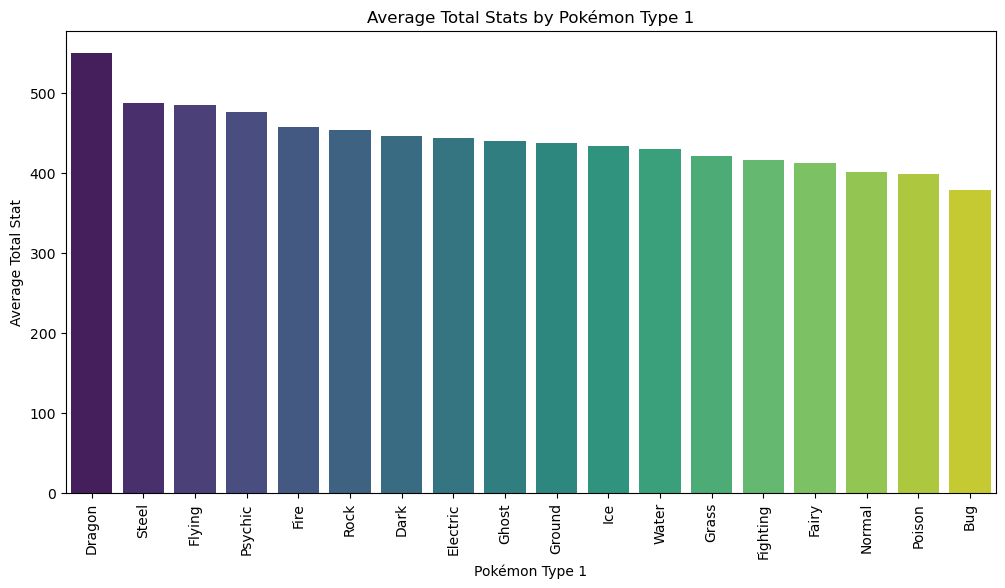

C:\Users\DELL\AppData\Local\Temp\ipykernel_3516\155499435.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type2_avg_stats.index, y=type2_avg_stats["Total"], palette="viridis")


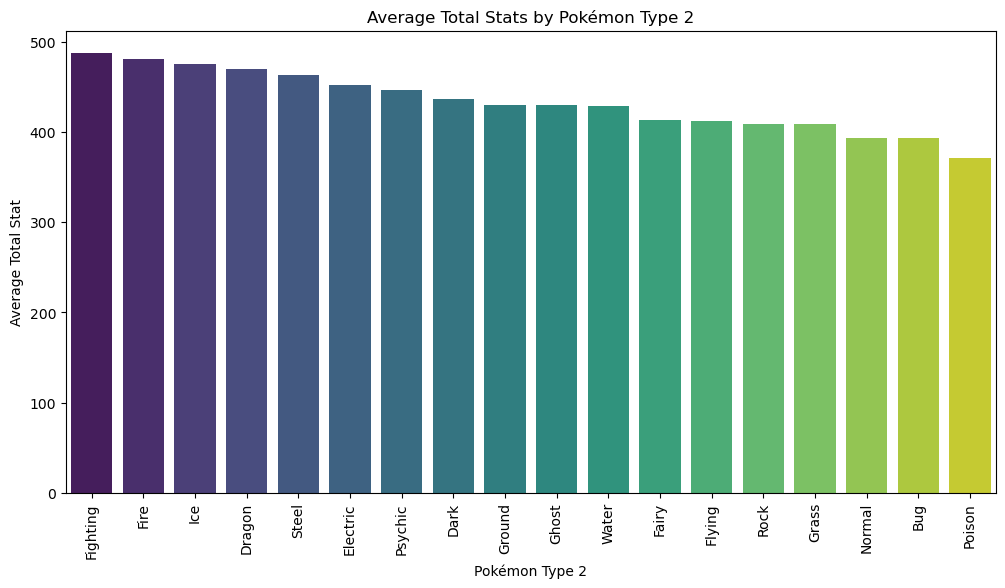

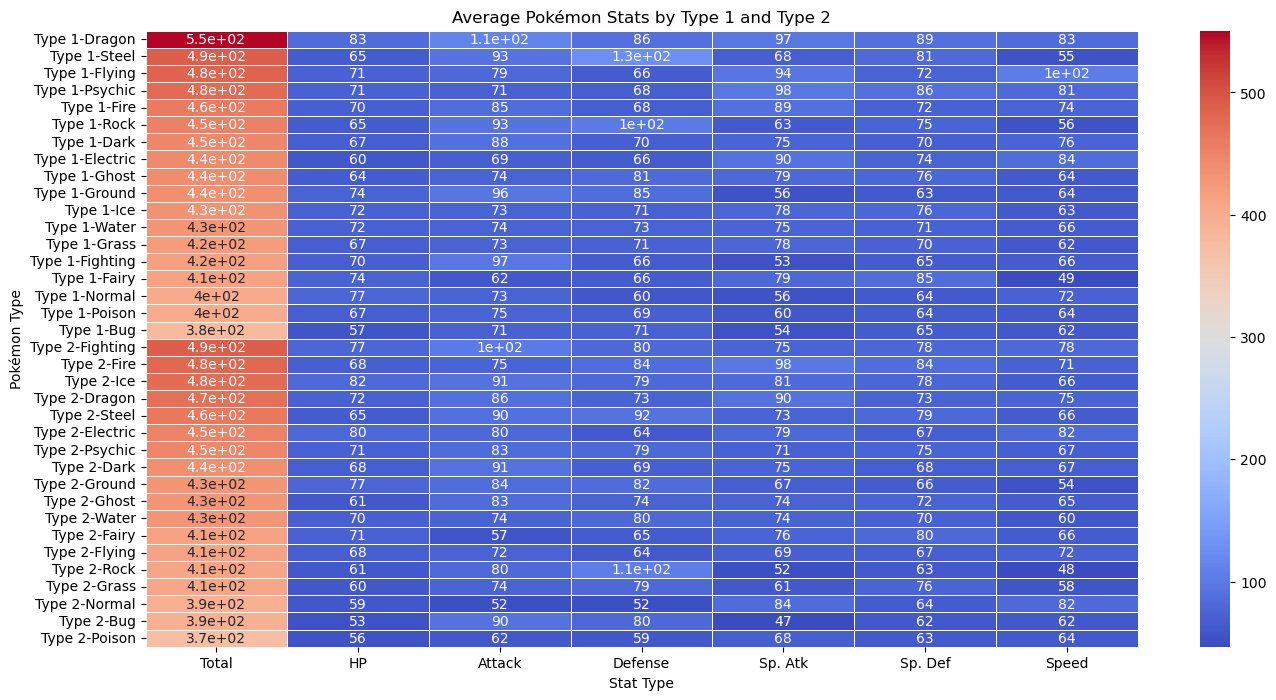

C:\Users\DELL\AppData\Local\Temp\ipykernel_3516\155499435.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x=type1_avg_stats.index, y=type1_avg_stats["Attack"], palette="magma")
C:\Users\DELL\AppData\Local\Temp\ipykernel_3516\155499435.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x=type2_avg_stats.index, y=type2_avg_stats["Attack"], palette="magma")


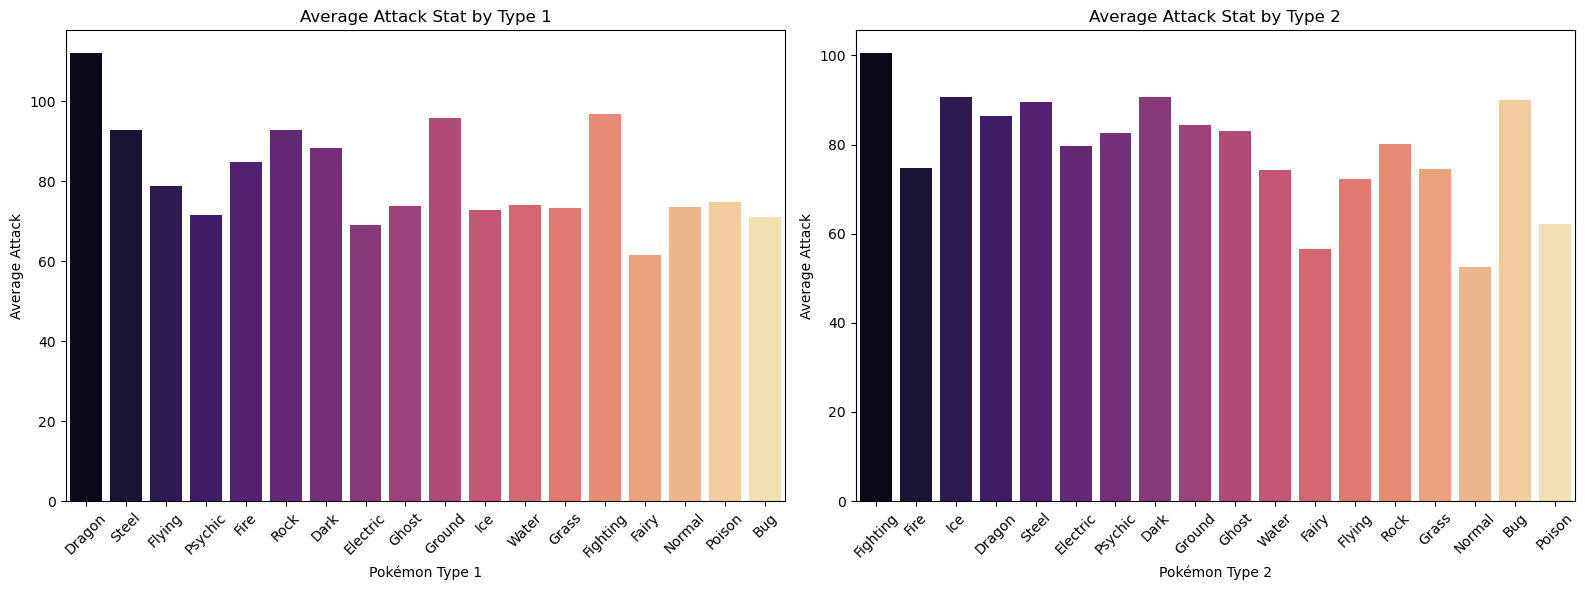

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("C:\\Users\\DELL\\Downloads\\pokemon_data_filled_by_stats.csv")

# 1. Group by 'Type 1' and 'Type 2' and calculate the mean for relevant stats
type1_avg_stats = df.groupby("Type 1")[["Total", "HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]].mean()
type2_avg_stats = df.groupby("Type 2")[["Total", "HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]].mean()

# Sorting the data for better visualization
type1_avg_stats = type1_avg_stats.sort_values(by="Total", ascending=False)
type2_avg_stats = type2_avg_stats.sort_values(by="Total", ascending=False)

# Print the average stats for each Type 1 and Type 2
print("Average Stats by Type 1:")
print(type1_avg_stats)
print("\nAverage Stats by Type 2:")
print(type2_avg_stats)

# Barplot of Average 'Total' stat by Type 1
plt.figure(figsize=(12, 6))
sns.barplot(x=type1_avg_stats.index, y=type1_avg_stats["Total"], palette="viridis")
plt.xticks(rotation=90)
plt.title("Average Total Stats by Pokémon Type 1")
plt.xlabel("Pokémon Type 1")
plt.ylabel("Average Total Stat")
plt.show()

# 3. Barplot of Average 'Total' stat by Type 2
plt.figure(figsize=(12, 6))
sns.barplot(x=type2_avg_stats.index, y=type2_avg_stats["Total"], palette="viridis")
plt.xticks(rotation=90)
plt.title("Average Total Stats by Pokémon Type 2")
plt.xlabel("Pokémon Type 2")
plt.ylabel("Average Total Stat")
plt.show()

# 4. Heatmap of Average Stats by Type 1 and Type 2
# Combine the results for both Type 1 and Type 2 to display together
avg_stats_combined = pd.concat([type1_avg_stats, type2_avg_stats], keys=["Type 1", "Type 2"])
plt.figure(figsize=(16, 8))
sns.heatmap(avg_stats_combined, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Average Pokémon Stats by Type 1 and Type 2")
plt.xlabel("Stat Type")
plt.ylabel("Pokémon Type")
plt.show()

# 5. Comparison of Average Attack by Type 1 and Type 2
# Plot side by side for Attack Stat (Type 1 and Type 2 comparison)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(ax=axes[0], x=type1_avg_stats.index, y=type1_avg_stats["Attack"], palette="magma")
axes[0].set_title("Average Attack Stat by Type 1")
axes[0].set_xlabel("Pokémon Type 1")
axes[0].set_ylabel("Average Attack")
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(ax=axes[1], x=type2_avg_stats.index, y=type2_avg_stats["Attack"], palette="magma")
axes[1].set_title("Average Attack Stat by Type 2")
axes[1].set_xlabel("Pokémon Type 2")
axes[1].set_ylabel("Average Attack")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Correlation Matrix:
            Total        HP    Attack   Defense   Sp. Atk   Sp. Def     Speed
Total    1.000000  0.618748  0.736211  0.612787  0.747250  0.717609  0.575943
HP       0.618748  1.000000  0.422386  0.239622  0.362380  0.378718  0.175952
Attack   0.736211  0.422386  1.000000  0.438687  0.396362  0.263990  0.381240
Defense  0.612787  0.239622  0.438687  1.000000  0.223549  0.510747  0.015227
Sp. Atk  0.747250  0.362380  0.396362  0.223549  1.000000  0.506121  0.473018
Sp. Def  0.717609  0.378718  0.263990  0.510747  0.506121  1.000000  0.259133
Speed    0.575943  0.175952  0.381240  0.015227  0.473018  0.259133  1.000000


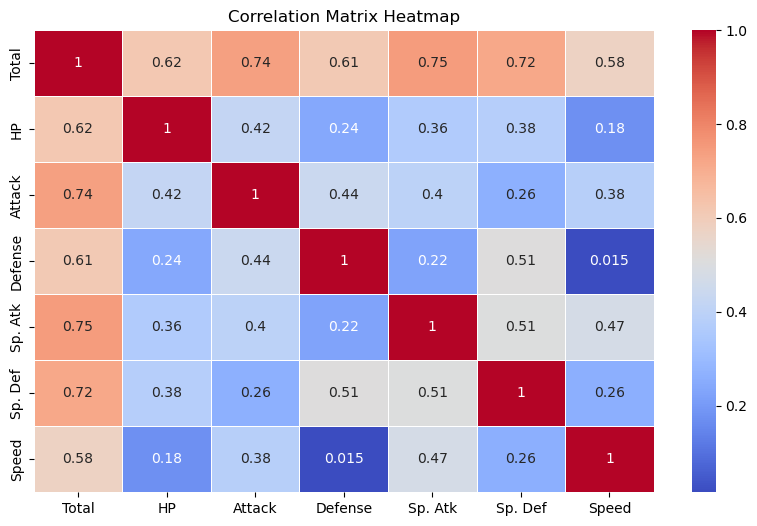

In [2]:
#1.2 1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("C:\\Users\\DELL\\Downloads\\pokemon_data_filled_by_stats.csv")

# Select only numerical columns
numerical_columns = ["Total", "HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
correlation_matrix = df[numerical_columns].corr()

# Print correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

# Visualize the correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()


In [4]:
# Extract strong and weak correlations
strong_corr = correlation_matrix[(correlation_matrix > 0.7) & (correlation_matrix < 1)]
weak_corr = correlation_matrix[correlation_matrix < 0.3]

print("\nStrong Correlations:\n", strong_corr.dropna(how="all"))
print("\nWeak Correlations:\n", weak_corr.dropna(how="all"))



Strong Correlations:
             Total  HP    Attack  Defense  Sp. Atk   Sp. Def  Speed
Total         NaN NaN  0.736211      NaN  0.74725  0.717609    NaN
Attack   0.736211 NaN       NaN      NaN      NaN       NaN    NaN
Sp. Atk  0.747250 NaN       NaN      NaN      NaN       NaN    NaN
Sp. Def  0.717609 NaN       NaN      NaN      NaN       NaN    NaN

Weak Correlations:
          Total        HP   Attack   Defense   Sp. Atk   Sp. Def     Speed
HP         NaN       NaN      NaN  0.239622       NaN       NaN  0.175952
Attack     NaN       NaN      NaN       NaN       NaN  0.263990       NaN
Defense    NaN  0.239622      NaN       NaN  0.223549       NaN  0.015227
Sp. Atk    NaN       NaN      NaN  0.223549       NaN       NaN       NaN
Sp. Def    NaN       NaN  0.26399       NaN       NaN       NaN  0.259133
Speed      NaN  0.175952      NaN  0.015227       NaN  0.259133       NaN


In [41]:
# Extract correlations
strong_corr = correlation_matrix[(correlation_matrix >= 0.7) & (correlation_matrix < 1)]
moderate_corr = correlation_matrix[(correlation_matrix >= 0.5) & (correlation_matrix < 0.7)]
weak_corr = correlation_matrix[correlation_matrix < 0.3]

# Drop NaN rows for better readability
print("\nStrong Correlations (|r| ≥ 0.7):\n", strong_corr.dropna(how="all"))
print("\nModerate Correlations (0.5 ≤ |r| < 0.7):\n", moderate_corr.dropna(how="all"))
print("\nWeak Correlations (|r| < 0.3):\n", weak_corr.dropna(how="all"))



Strong Correlations (|r| ≥ 0.7):
             Total  HP    Attack  Defense  Sp. Atk   Sp. Def  Speed
Total         NaN NaN  0.736211      NaN  0.74725  0.717609    NaN
Attack   0.736211 NaN       NaN      NaN      NaN       NaN    NaN
Sp. Atk  0.747250 NaN       NaN      NaN      NaN       NaN    NaN
Sp. Def  0.717609 NaN       NaN      NaN      NaN       NaN    NaN

Moderate Correlations (0.5 ≤ |r| < 0.7):
             Total        HP  Attack   Defense   Sp. Atk   Sp. Def     Speed
Total         NaN  0.618748     NaN  0.612787       NaN       NaN  0.575943
HP       0.618748       NaN     NaN       NaN       NaN       NaN       NaN
Defense  0.612787       NaN     NaN       NaN       NaN  0.510747       NaN
Sp. Atk       NaN       NaN     NaN       NaN       NaN  0.506121       NaN
Sp. Def       NaN       NaN     NaN  0.510747  0.506121       NaN       NaN
Speed    0.575943       NaN     NaN       NaN       NaN       NaN       NaN

Weak Correlations (|r| < 0.3):
          Total        

In [43]:
# 2.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("C:\\Users\\DELL\\Downloads\\pokemon_data_filled_by_stats.csv")

# Select only numerical columns
numerical_columns = ["Total", "HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
correlation_matrix = df[numerical_columns].corr()

# Categorize correlations
strong_corr = correlation_matrix[(correlation_matrix >= 0.7) & (correlation_matrix < 1)]
moderate_corr = correlation_matrix[(correlation_matrix >= 0.5) & (correlation_matrix < 0.7)]


# Drop NaN rows for readability
print("\n Strong Correlations (|r| ≥ 0.7):\n", strong_corr.dropna(how="all"))
print("\n Moderate Correlations (0.5 ≤ |r| < 0.7):\n", moderate_corr.dropna(how="all"))

# Final Summary of Relationships 
summary = []

# Function to extract meaningful relationships
def extract_relationships(correlation_df, strength_label):
    for row in correlation_df.itertuples():
        for col, value in zip(correlation_df.columns, row[1:]):
            if not pd.isna(value):  # Ignore NaN values
                summary.append(f"{row[0]} and {col} → {strength_label} correlation ({value:.2f})")

# Extract from strong, moderate, and weak correlations
extract_relationships(strong_corr, "STRONG")
extract_relationships(moderate_corr, "MODERATE")

# Print final summary
print("\n Final Summary of Correlations:")
for rel in summary:
    print(f"- {rel}")



 Strong Correlations (|r| ≥ 0.7):
             Total  HP    Attack  Defense  Sp. Atk   Sp. Def  Speed
Total         NaN NaN  0.736211      NaN  0.74725  0.717609    NaN
Attack   0.736211 NaN       NaN      NaN      NaN       NaN    NaN
Sp. Atk  0.747250 NaN       NaN      NaN      NaN       NaN    NaN
Sp. Def  0.717609 NaN       NaN      NaN      NaN       NaN    NaN

 Moderate Correlations (0.5 ≤ |r| < 0.7):
             Total        HP  Attack   Defense   Sp. Atk   Sp. Def     Speed
Total         NaN  0.618748     NaN  0.612787       NaN       NaN  0.575943
HP       0.618748       NaN     NaN       NaN       NaN       NaN       NaN
Defense  0.612787       NaN     NaN       NaN       NaN  0.510747       NaN
Sp. Atk       NaN       NaN     NaN       NaN       NaN  0.506121       NaN
Sp. Def       NaN       NaN     NaN  0.510747  0.506121       NaN       NaN
Speed    0.575943       NaN     NaN       NaN       NaN       NaN       NaN

 Final Summary of Correlations:
- Total and Attack →

In [45]:
#3.
import pandas as pd
import numpy as np
import itertools

# numerical columns
numerical_columns = ["Total", "HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
n = len(df)  # Number of observations

# Significance level (alpha = 0.05 for 95% confidence)
alpha = 0.05
significant_results = []

# Function to compute Pearson's correlation
def pearson_corr(x, y):
    x_mean, y_mean = np.mean(x), np.mean(y)
    numerator = np.sum((x - x_mean) * (y - y_mean))
    denominator = np.sqrt(np.sum((x - x_mean) ** 2) * np.sum((y - y_mean) ** 2))
    return numerator / denominator if denominator != 0 else 0

# Function to compute t-score
def compute_t_stat(r, n):
    return (r * np.sqrt(n - 2)) / np.sqrt(1 - r**2)

# Function to determine significance
def is_significant(t_value, df, alpha=0.05):
    # Approximate critical t-value for df=n-2 (for large df, use 1.96 for 95% confidence)
    critical_t_value = 1.96 if df > 30 else 2.048  # Approximation
    return "Significant" if abs(t_value) > critical_t_value else "Not Significant"

# Perform hypothesis testing for each pair of numerical features
for feature1, feature2 in itertools.combinations(numerical_columns, 2):
    r_value = pearson_corr(df[feature1], df[feature2])
    t_value = compute_t_stat(r_value, n)
    significance = is_significant(t_value, n - 2, alpha)

    # Store results
    significant_results.append((feature1, feature2, round(r_value, 2), round(t_value, 2), significance))

# Convert results to a DataFrame for better readability
results_df = pd.DataFrame(significant_results, columns=["Feature 1", "Feature 2", "Correlation (r)", "t-value", "Significance"])

# Print results
print("\n Hypothesis Testing Results:")
print(results_df)



 Hypothesis Testing Results:
   Feature 1 Feature 2  Correlation (r)  t-value     Significance
0      Total        HP             0.62    22.25      Significant
1      Total    Attack             0.74    30.73      Significant
2      Total   Defense             0.61    21.91      Significant
3      Total   Sp. Atk             0.75    31.76      Significant
4      Total   Sp. Def             0.72    29.11      Significant
5      Total     Speed             0.58    19.90      Significant
6         HP    Attack             0.42    13.16      Significant
7         HP   Defense             0.24     6.97      Significant
8         HP   Sp. Atk             0.36    10.98      Significant
9         HP   Sp. Def             0.38    11.56      Significant
10        HP     Speed             0.18     5.05      Significant
11    Attack   Defense             0.44    13.79      Significant
12    Attack   Sp. Atk             0.40    12.20      Significant
13    Attack   Sp. Def             0.26     7.

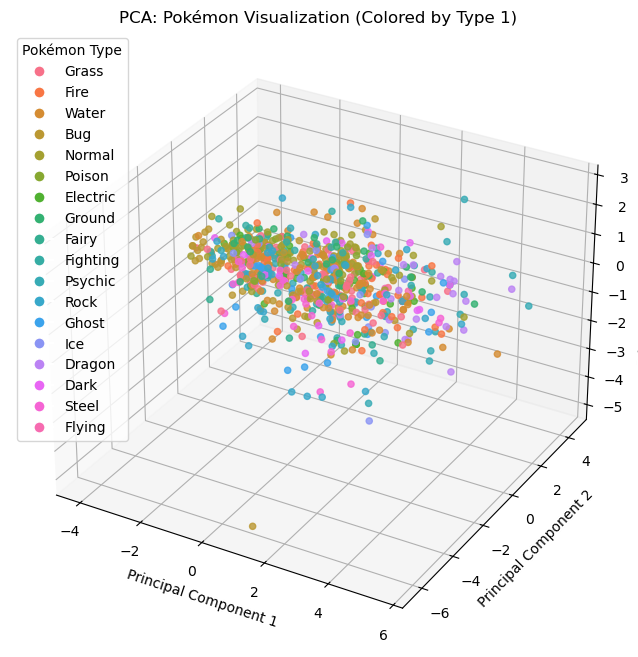

In [92]:
##4
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# Load Data 
numerical_columns = ["Total", "HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
X = df[numerical_columns].values

# Standardize the Data (Z-score normalization)
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
Z = (X - X_mean) / X_std

# Compute Covariance Matrix
cov_matrix = np.cov(Z, rowvar=False)

# Compute Eigenvalues and Eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort Eigenvalues & Eigenvectors
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

# Select top 3 principal components
top_3_components = eigenvectors[:, :3]

# Project data onto PCA space
X_pca = Z @ top_3_components

# Convert to DataFrame for easy plotting
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2", "PC3"])
df_pca["Type 1"] = df["Type 1"]  # Add Pokémon Type for color coding

# Get unique Pokémon types and assign colors
unique_types = df_pca["Type 1"].unique()
palette = sns.color_palette("husl", len(unique_types))  # Generate distinct colors
color_dict = {ptype: palette[i] for i, ptype in enumerate(unique_types)}

# Map colors to Pokémon types
colors = df_pca["Type 1"].map(color_dict)

# 3D Visualization
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(df_pca["PC1"], df_pca["PC2"], df_pca["PC3"], c=colors, alpha=0.8)

# Labels & Titles
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("PCA: Pokémon Visualization (Colored by Type 1)")

# Legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_dict[ptype], markersize=8) for ptype in unique_types]
ax.legend(handles, unique_types, title="Pokémon Type", loc="best")

plt.show()


In [29]:
# Compute explained variance ratio
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

# Print variance explained by each component
for i, var in enumerate(explained_variance_ratio[:5]):  # Show first 5 PCs
    print(f"Principal Component {i+1} explains {var*100:.2f}% of the variance.")

## Since the first 3 account for a sum of 79.74% of vraiance, we plot the first 3 PCA above


Principal Component 1 explains 52.99% of the variance.
Principal Component 2 explains 15.62% of the variance.
Principal Component 3 explains 11.13% of the variance.
Principal Component 4 explains 10.32% of the variance.
Principal Component 5 explains 6.12% of the variance.


In [33]:
# Create a DataFrame for PCA Loadings (how much each stat contributes to each PC)
pca_loadings = pd.DataFrame(
    eigenvectors[:, :3],  # First 3 Principal Components
    index=numerical_columns,  # Original Stat Names
    columns=["PC1", "PC2", "PC3"]
)

# Display the PCA loadings
print(pca_loadings)


              PC1       PC2       PC3
Total    0.518868  0.007124  0.006491
HP       0.329319 -0.088082  0.466661
Attack   0.378075  0.008992  0.593397
Defense  0.313146 -0.631028 -0.069251
Sp. Atk  0.390094  0.301919 -0.308869
Sp. Def  0.380027 -0.242612 -0.568863
Speed    0.291085  0.666256 -0.079153


5. In competitive Pokémon battles, the correlations between various Pokémon stats can provide key insights into how Pokémon perform, how they should be used in teams, and how they interact with other Pokémon. 

1. Total Stats and Battle Performance:
- Correlation: We observed that Total Stats have a strong positive correlation with various individual stats like Attack, Defense, Special Defense, and Speed. This makes sense, as higher Total stats typically represent Pokémon that are well-rounded or have enhanced capabilities across multiple aspects of battle (both offense and defense).
  Implication: 
  - High Total Stats Pokémon (often Legendaries or Pseudo-Legendaries) are generally better suited for competitive battles due to their balanced or specialized high stats. They can often withstand attacks, deal considerable damage, and have the versatility to adapt to various roles in a team (e.g., offensive, defensive, or supportive).
  - Teams with high Total Stats Pokémon would typically dominate in terms of sheer power and bulk, but they can be countered by Pokémon with specific strengths (e.g., faster Pokémon or those with status moves).

2. Attack vs. Defense and Special Defense:
- Correlation: We noticed a moderate positive correlation between Attack and Defense (0.44) and Special Attack with Special Defense (0.51). This suggests that Pokémon with higher offensive stats (e.g., Attack or Special Attack) tend to have better defensive capabilities (e.g., Defense or Special Defense).
  Implication:
  - Offensive and Defensive Synergy: Pokémon with both high Attack and high Defense are often "balanced" Pokémon that can handle various roles—both attacking and taking hits. A good example of this could be bulky attackers like Tyranitar, which has both strong physical and special stats.
  - Conversely, Pokémon that focus on either Attack or Defense might be more specialized (e.g., Sweeper or Tank roles). For instance, a Glass Cannon might have extremely high Attack but low Defense, making it vulnerable despite its offensive strength.

3. Sp. Atk and Speed:
- Correlation: Special Attack (Sp. Atk) and Speed have a moderate positive correlation (0.51). Pokémon with higher Special Attack also tend to have higher Speed. This implies that faster Pokémon (like Alakazam or Jolteon) often have more powerful Special Attacks.
  Implication:
  - Fast Special Attackers: These Pokémon are typically sweepers. They can deal a significant amount of damage before the opponent can react, making them valuable in high-speed, high-damage roles. Their high Speed ensures that they get the first strike, while their Special Attack ensures that the strike deals significant damage.
  - Speed vs. Bulk: Pokémon that have a trade-off between Speed and Bulk may struggle to deal damage quickly, but their tankiness allows them to survive longer, thus potentially outlasting opponents in longer battles (e.g., Blissey or Snorlax). These slower, bulkier Pokémon can be paired with offensive teammates for synergy.

 4. Speed and Total Stats:
- Correlation: Speed shows a moderate correlation with Total Stats (0.62). This suggests that Pokémon with higher overall stats also tend to be faster, and this speed is critical in determining the flow of the battle.
  Implication:
  - Speed as a Key Factor: Pokémon with higher Speed are crucial for out-speeding and defeating opponents before they can act. For example, fast Pokémon like Ninjask or Accelgor can strike first with powerful moves, potentially knocking out slower enemies before they get a chance to retaliate.
  - Speed Control: Teams with slower Pokémon may need to rely on strategies such as priority moves (e.g., Bullet Punch or Sucker Punch) or status moves (e.g., Thunder Wave or Trick Room) to overcome faster opponents.

 5. Special Defense and Defense
- Correlation: Special Defense (Sp. Def) is moderately correlated with Defense (0.61). This means that Pokémon that are physically bulky (high Defense) often also have good Special Defense, which is essential for taking both physical and special hits.
  
  Implication:
  - Balanced Defenders: Pokémon with both high Defense and Special Defense (such as Shuckle or Steelix) are exceptional tanks that can withstand hits from both physical and special attackers. These Pokémon are often used as walls in battle, absorbing damage for longer.
  - Specialized Defenders: Pokémon that focus on just one defense type (physical or special) might be more vulnerable to attacks from the opposite category. For example, a Pokémon with low Special Defense might be susceptible to powerful special moves, while one with low Defense might struggle against physical attackers.

6. Attack and Special Attack:
- Correlation: While Attack and Special Attack aren't perfectly correlated, they do show some moderate correlation (0.51). This means that Pokémon that excel in one offensive stat (Attack or Special Attack) often have a reasonable amount of power in the other stat as well.
  Implication:
  - Mixed Attackers: Pokémon with both high Attack and Special Attack (e.g., Charizard, Gardevoir) are versatile in their offensive approach, being able to hit opponents physically and specially. This flexibility allows them to surprise opponents with their wide range of moves (physical or special).
  - However, purely physical or purely special attackers might have more focused offensive strategies, which could be either advantageous or limiting depending on the matchup.

 7. Legendary Pokémon and Battle Roles:
- Correlation: Legendary Pokémon generally have very high Total Stats, which strongly correlates with their exceptional power and versatility in battle.
  Implication:
  - High Total Stat Pokémon (e.g., Mewtwo, Rayquaza) often dominate competitive battles due to their high offensive and defensive capabilities. They can take on various roles in a team (e.g., offensive powerhouse, special attacker, bulky support).
  - The Legendary status often means that they are more difficult to counter, making them key targets for team building. Banning or limiting the use of Legendary Pokémon in certain formats helps to maintain balance in competitive play.

Conclusion
By understanding the correlations between Pokémon stats (Total, Attack, Defense, Speed, etc.), we can then strategically build teams and form battle strategies. The key implications of these correlations are:
1. Balanced Pokémon (with strong Total Stats) are generally more versatile and useful in competitive battles.
2. Speed is a critical factor, with faster Pokémon often gaining an advantage in battle.
3. Offensive/Defensive Synergy helps in determining whether a Pokémon is a sweeper (offensive) or a tank (defensive).
4. Pokémon that balance physical and special defenses are crucial for handling all types of attackers.
5. Legendary Pokémon, due to their high stats, often define the competitive meta and may need to be used wisely or limited in team formats.
These correlations can thus help guide decisions on which Pokémon to include in a team, how to build effective battle strategies, and how to counter potential threats in competitive play.

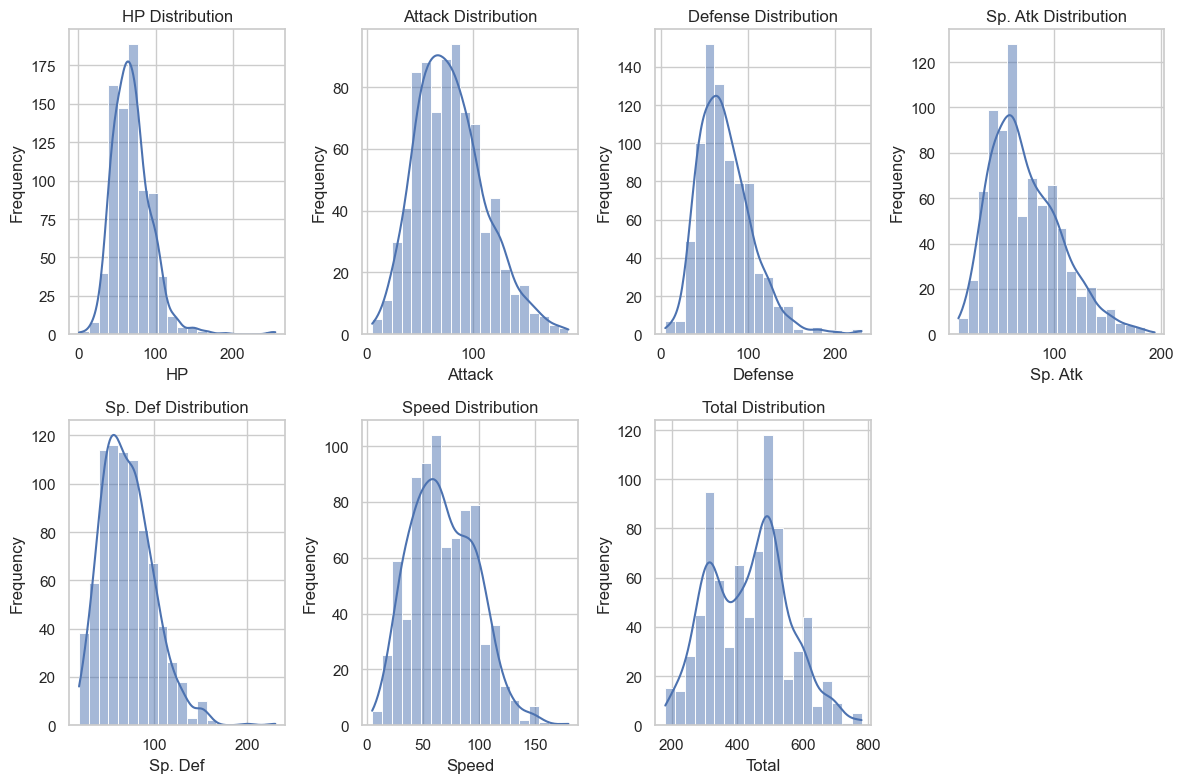

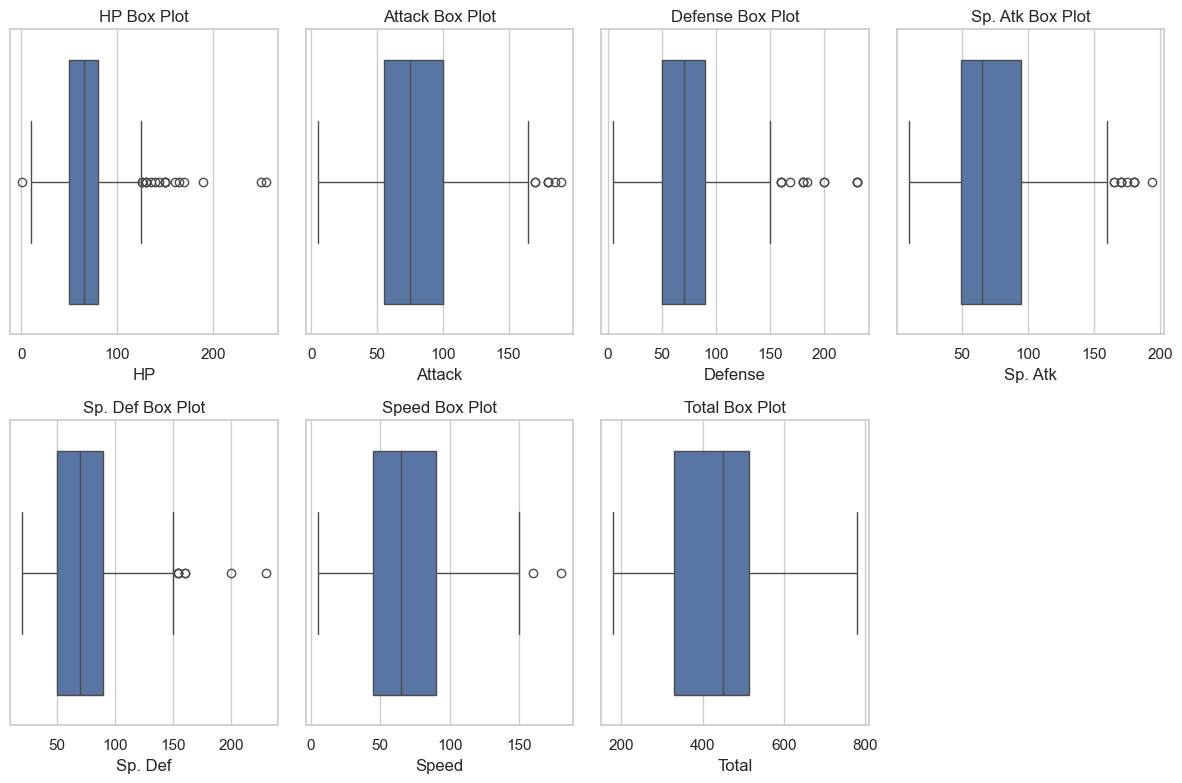

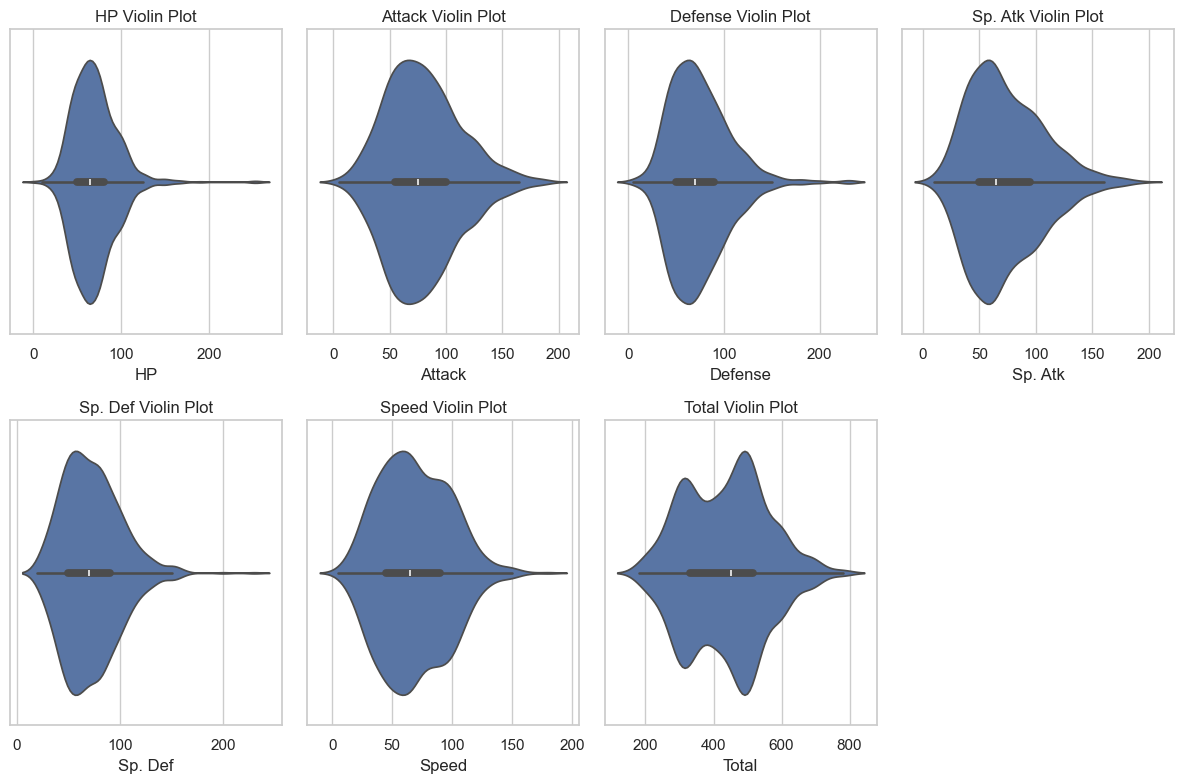

In [71]:
#1.3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("C:\\Users\\DELL\\Downloads\\pokemon_data_filled_by_stats.csv")

# style for the plots
sns.set(style="whitegrid")

# List of stats columns for plotting
stats_columns = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Total']

# 1. Histogram Plot for each stat
plt.figure(figsize=(12, 8))
for i, stat in enumerate(stats_columns, 1):
    plt.subplot(2, 4, i)  # Plot in a 2x4 grid
    sns.histplot(df[stat], kde=True, bins=20)
    plt.title(f'{stat} Distribution')
    plt.xlabel(stat)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# 2. Box Plot for each stat
plt.figure(figsize=(12, 8))
for i, stat in enumerate(stats_columns, 1):
    plt.subplot(2, 4, i)  # Plot in a 2x4 grid
    sns.boxplot(x=df[stat])
    plt.title(f'{stat} Box Plot')
    plt.xlabel(stat)
plt.tight_layout()
plt.show()

# 3. Violin Plot for each stat
plt.figure(figsize=(12, 8))
for i, stat in enumerate(stats_columns, 1):
    plt.subplot(2, 4, i)  # Plot in a 2x4 grid
    sns.violinplot(x=df[stat])
    plt.title(f'{stat} Violin Plot')
    plt.xlabel(stat)
plt.tight_layout()
plt.show()


Accuracy: 0.80625
Precision: 0.29357798165137616
Recall: 0.9846153846153847
F1-Score: 0.45229681978798586

Confusion Matrix:
[[581 154]
 [  1  64]]


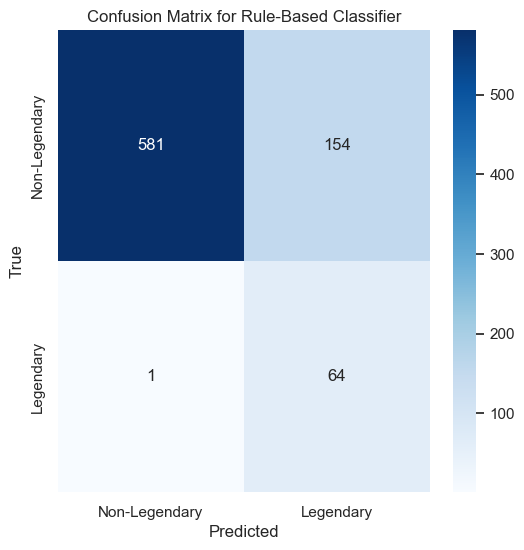


Misclassified Pokémon:
     Total  Attack  Defense  Sp. Atk  Sp. Def  Speed
2      525      82       83      100      100     80
3      625     100      123      122      120     80
6      534      84       78      109       85    100
7      634     130      111      130       85    100
8      634     104       78      159      115    100
..     ...     ...      ...      ...      ...    ...
769    521      77       72       99       92     58
770    525      65       65      110      130     60
776    600     100       70      110      150     80
789    514     117      184       44       46     28
791    535      70       80       97       80    123

[155 rows x 6 columns]


In [73]:
#2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("C:\\Users\\DELL\\Downloads\\pokemon_data_filled_by_stats.csv")

# Data Preprocessing
# Drop 'Name' and 'Type 1', 'Type 2' columns as they are non-numeric
df = df.drop(columns=['Name', 'Type 1', 'Type 2'])

# Handle missing values
df = df.dropna()

# Convert 'Legendary' to binary values (1 for Legendary, 0 for Non-Legendary)
df['Legendary'] = df['Legendary'].astype(int)

# Feature columns
X = df.drop(columns=['Legendary'])
y = df['Legendary']

# Custom Rule-Based Classifier 
def rule_based_classifier(pokemon_stats):
    total_stat = pokemon_stats['Total']
    attack = pokemon_stats['Attack']
    defense = pokemon_stats['Defense']
    sp_atk = pokemon_stats['Sp. Atk']
    sp_def = pokemon_stats['Sp. Def']
    speed = pokemon_stats['Speed']
    
    # Define thresholds based on general Pokémon knowledge
    if total_stat > 500 and attack > 100 and defense > 100 and sp_atk > 100:
        return 1  # Legendary
    elif total_stat > 500 and (attack > 90 or defense > 90 or sp_atk > 90):
        return 1  # Legendary (a bit weaker but still likely a Legendary)
    else:
        return 0  # Non-Legendary

# Apply the rule-based classifier to the dataset
y_pred = X.apply(rule_based_classifier, axis=1)

# Calculate Performance Metrics
# Accuracy = (True Positives + True Negatives) / Total
accuracy = np.sum(y == y_pred) / len(y)

# Confusion Matrix manually
TP = np.sum((y == 1) & (y_pred == 1))  # True Positives
TN = np.sum((y == 0) & (y_pred == 0))  # True Negatives
FP = np.sum((y == 0) & (y_pred == 1))  # False Positives
FN = np.sum((y == 1) & (y_pred == 0))  # False Negatives

# Precision = TP / (TP + FP)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0

# Recall = TP / (TP + FN)
recall = TP / (TP + FN) if (TP + FN) > 0 else 0

# F1-Score = 2 * (Precision * Recall) / (Precision + Recall)
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

# Results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1_score)

# Confusion Matrix
print("\nConfusion Matrix:")
conf_matrix = np.array([[TN, FP], [FN, TP]])
print(conf_matrix)

# Visualize Confusion Matrix
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", xticklabels=['Non-Legendary', 'Legendary'], yticklabels=['Non-Legendary', 'Legendary'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Rule-Based Classifier')
plt.show()

# Misclassified Pokémon
misclassified = X.loc[(y != y_pred), :]
print("\nMisclassified Pokémon:")
print(misclassified[['Total', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']])



Accuracy: 0.9750
Precision: 0.8462
Recall: 0.8462
F1-Score: 0.8462

Confusion Matrix:
[[145   2]
 [  2  11]]


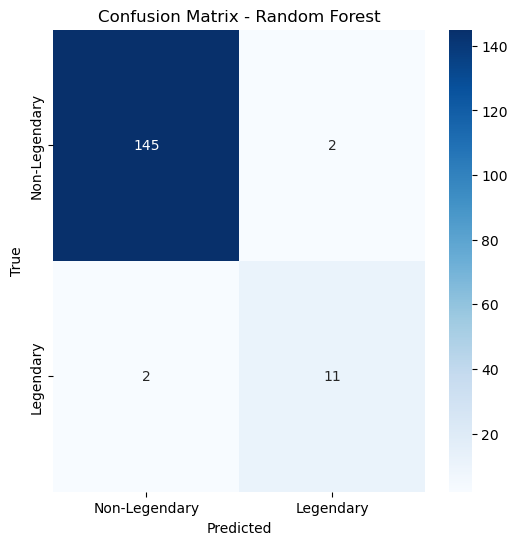

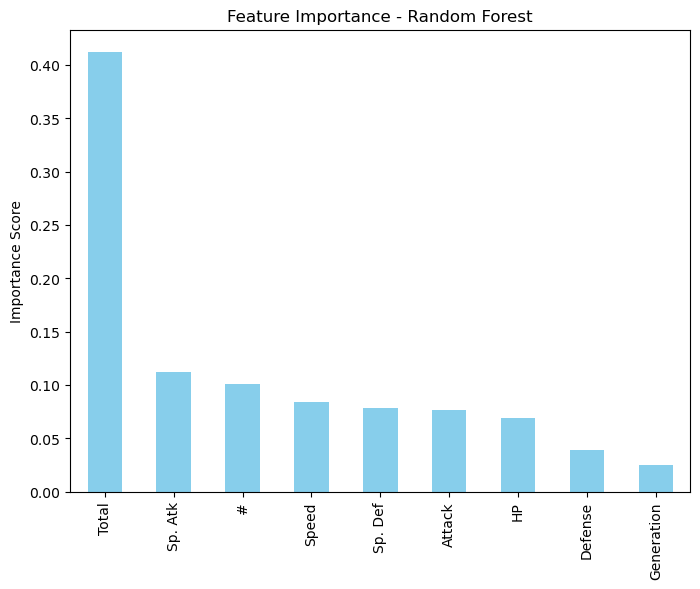


Misclassified Pokémon:
       #  Total   HP  Attack  Defense  Sp. Atk  Sp. Def  Speed  Generation
548  490    600  100     100      100      100      100    100           4
546  488    600  120      70      120       75      130     85           4
414  377    580   80     100      200       50      100     50           3
549  491    600   70      90       90      135       90    125           4


In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

df = pd.read_csv("C:\\Users\\DELL\\Downloads\\pokemon_data_filled_by_stats.csv")

# Drop non-numeric columns
df = df.drop(columns=['Name', 'Type 1', 'Type 2'])

# Convert 'Legendary' to binary values
df['Legendary'] = df['Legendary'].astype(int)

# Features and target
X = df.drop(columns=['Legendary'])
y = df['Legendary']

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Display results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)

# Visualize Confusion Matrix
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", xticklabels=['Non-Legendary', 'Legendary'], yticklabels=['Non-Legendary', 'Legendary'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Random Forest')
plt.show()

# Feature Importance
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
feature_importances.plot(kind='bar', color='skyblue')
plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance Score")
plt.show()

# Find misclassified Pokémon
misclassified = X_test[(y_test != y_pred)]
print("\nMisclassified Pokémon:")
print(misclassified)


Accuracy: 0.9375
Precision: 1.0000
Recall: 0.2308
F1-Score: 0.3750

Confusion Matrix:
[[147   0]
 [ 10   3]]


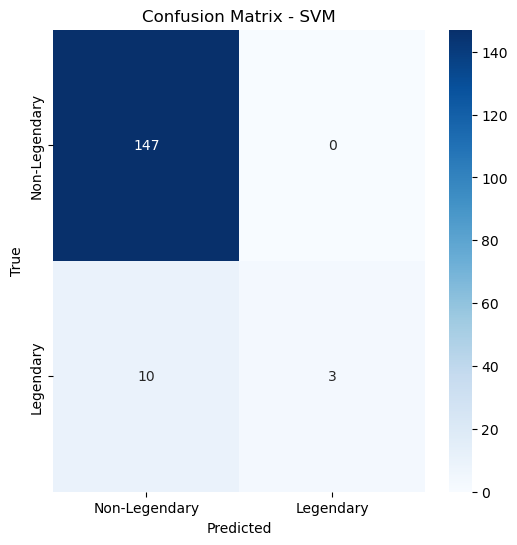


Misclassified Pokémon:
       #  Total   HP  Attack  Defense  Sp. Atk  Sp. Def  Speed  Generation
158  146    580   90     100       90      125       85     90           1
699  638    580   91      90      129       90       72    108           5
709  645    600   89     145       90      105       80     91           5
156  144    580   90      85      100       95      125     85           1
414  377    580   80     100      200       50      100     50           3
794  718    600  108     100      121       81       95     95           6
428  386    600   50     150       50      150       50    150           3
549  491    600   70      90       90      135       90    125           4
795  719    600   50     100      150      100      150     50           6
705  642    580   79     105       70      145       80    101           5


In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

df = pd.read_csv("C:\\Users\\DELL\\Downloads\\pokemon_data_filled_by_stats.csv")

# Drop non-numeric columns
df = df.drop(columns=['Name', 'Type 1', 'Type 2'])

# Convert 'Legendary' to binary values
df['Legendary'] = df['Legendary'].astype(int)

# Features and target
X = df.drop(columns=['Legendary'])
y = df['Legendary']

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train SVM model
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

# Predictions
y_pred = svm_model.predict(X_test)

# Performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Display results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)

# Visualize Confusion Matrix
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", xticklabels=['Non-Legendary', 'Legendary'], yticklabels=['Non-Legendary', 'Legendary'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - SVM')
plt.show()

# Find misclassified Pokémon
misclassified = X_test[(y_test != y_pred)]
print("\nMisclassified Pokémon:")
print(misclassified)


Comparison of Models and Implications

Our analysis compared three different approaches to predicting whether a Pokémon is Legendary based on its stats: a Rule-Based Classifier, Random Forest, and Support Vector Machine (SVM). Each model exhibited unique strengths and weaknesses.

The Rule-Based Classifier demonstrated an exceptionally high recall (98.46%), meaning it successfully identified nearly all Legendary Pokémon. However, its precision was significantly low (29.36%), indicating a high number of false positives—many non-Legendary Pokémon were mistakenly classified as Legendary. This suggests that while a threshold-based approach can capture general trends, it lacks the flexibility to adapt to outliers or Pokémon with atypical stat distributions.

In contrast, the Random Forest model provided the most balanced performance, achieving an impressive accuracy of 97.50%, along with strong precision (84.62%) and recall (84.62%). This model effectively minimized both false positives and false negatives, making it the best choice for real-world application. Random Forest's ability to learn complex patterns from Pokémon stats allowed it to outperform the rule-based approach by reducing misclassifications while still identifying a high number of Legendary Pokémon correctly.

The SVM model, while achieving perfect precision (100%), suffered from a low recall (23.08%). This means it was overly conservative, avoiding false positives at the cost of failing to identify most Legendary Pokémon. While this approach ensures that every Pokémon classified as Legendary is indeed Legendary, it excludes many true Legendary Pokémon from recognition. Fine-tuning SVM hyperparameters, such as adjusting the regularization parameter or using different kernels, may improve its recall without sacrificing too much precision.

Implications:
This analysis highlights the importance of selecting an appropriate model based on the desired balance between precision and recall. If the goal is to capture as many Legendary Pokémon as possible, a high-recall model like the rule-based approach or a fine-tuned SVM could be beneficial. However, if minimizing false classifications is a priority, Random Forest stands out as the best option, striking the optimal balance between accuracy, precision, and recall. Future improvements could involve exploring more advanced techniques such as XGBoost or Neural Networks to further enhance predictive accuracy.


C:\Users\DELL\AppData\Local\Temp\ipykernel_3516\2799223261.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=df["Legendary"], y=df[stat], palette=["blue", "red"])
C:\Users\DELL\AppData\Local\Temp\ipykernel_3516\2799223261.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=df["Legendary"], y=df[stat], palette=["blue", "red"])
C:\Users\DELL\AppData\Local\Temp\ipykernel_3516\2799223261.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=df["Legendary"], y=df[stat], palette=["blue", "red"])
C:\Users\DELL\AppData\Local\Temp\i

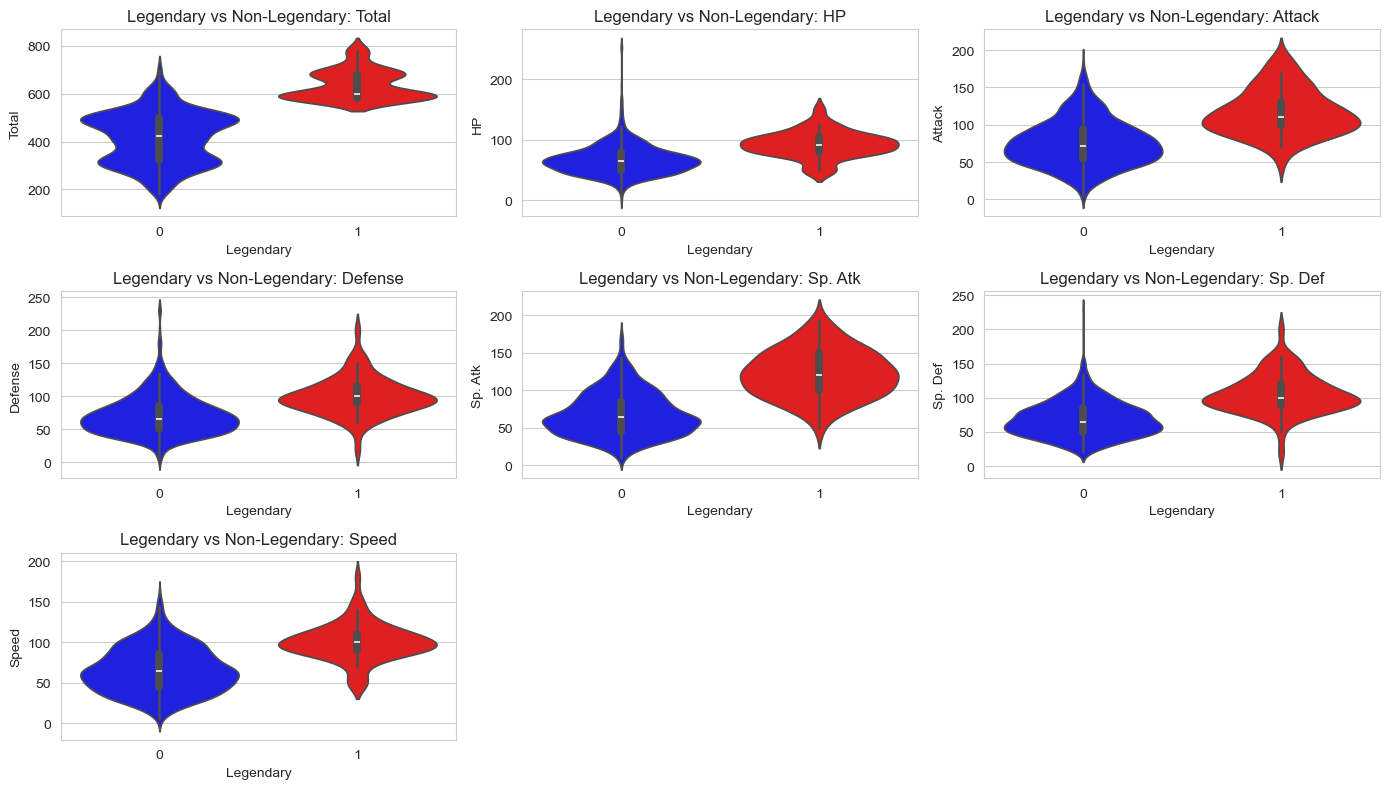

In [110]:
#EC:

import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for seaborn
sns.set_style("whitegrid")

# Split dataset into Legendary and Non-Legendary
legendary_pokemon = df[df["Legendary"] == True]
non_legendary_pokemon = df[df["Legendary"] == False]

# List of stats to analyze
stats = ["Total", "HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]

# Create violin plots for stat distributions
plt.figure(figsize=(14, 8))
for i, stat in enumerate(stats, 1):
    plt.subplot(3, 3, i)
    sns.violinplot(x=df["Legendary"], y=df[stat], palette=["blue", "red"])
    plt.title(f"Legendary vs Non-Legendary: {stat}")
    plt.xlabel("Legendary")
    plt.ylabel(stat)

plt.tight_layout()
plt.show()


Key Observations:

Legendary Pokémon have significantly higher "Total" stats—a clear separator between Legendary and Non-Legendary Pokémon.
Attack, Special Attack, and Speed tend to be higher for Legendary Pokémon, reinforcing their offensive power.
Defense and Special Defense also show a higher median for Legendaries, but with some overlap.
Some non-Legendary Pokémon have very high stats, suggesting potential outliers that could be re-evaluated as pseudo-Legendaries.

In [122]:
import numpy as np
file_path = r"C:\\Users\\DELL\\Downloads\\pokemon_data_filled_by_stats.csv"

df = pd.read_csv(file_path)
df["Legendary"] = df["Legendary"].astype(bool)

# Identify Pokémon with high Total stats but are NOT Legendary
high_stat_non_legendaries = df[(df["Total"] > 600) & (~df["Legendary"])]

# Define expected columns
expected_columns = ["Name", "Total", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]

# Check if required columns are present
missing_columns = set(expected_columns) - set(df.columns)
if missing_columns:
    print(f"Missing expected columns: {missing_columns}")
else:
    # Display these potential "pseudo-Legendary" Pokémon
    if high_stat_non_legendaries.empty:
        print("No non-Legendary Pokémon found with Total stats above 600.")
    else:
        display(high_stat_non_legendaries[expected_columns])


,Name,Total,Attack,Defense,Sp. Atk,Sp. Def,Speed
3,VenusaurMega Venusaur,625,100,123,122,120,80
7,CharizardMega Charizard X,634,130,111,130,85,100
8,CharizardMega Charizard Y,634,104,78,159,115,100
12,BlastoiseMega Blastoise,630,103,120,135,115,78
141,GyaradosMega Gyarados,640,155,109,70,130,81
154,AerodactylMega Aerodactyl,615,135,85,70,95,150
196,AmpharosMega Ampharos,610,95,105,165,110,45
224,SteelixMega Steelix,610,125,230,55,95,30
268,TyranitarMega Tyranitar,700,164,150,95,120,71
275,SceptileMega Sceptile,630,110,75,145,85,145


Outliers: High-Stat Non-Legendary Pokémon
Interesting Findings:
Many Mega Evolutions (e.g., Mega Tyranitar, Mega Salamence, Mega Metagross) have stats comparable to Legendaries but are not classified as such.
Slaking (670 Total Stats) is an outlier among non-Mega Pokémon, but its ability (Truant) holds it back.
Pseudo-Legendary Pokémon (e.g., Garchomp, Metagross, Salamence) have 700 Total Stats, making them as strong as some Legendaries.

 Why is this Important?  
1. Game Balance & Competitive Play  
   - Despite having stats similar to Legendaries, pseudo-Legendary Pokémon and Mega Evolutions often have abilities, typing, or move limitations that balance them.  
   - Example: Slaking (670 Total Stats) has incredible power, but its Truant ability makes it ineffective in battle.  
   - Understanding these differences helps in team building and strategy for competitive play.  
2. Rarity vs. Strength 
   - Not all powerful Pokémon are classified as Legendary—this means players can access high-stat Pokémon without event restrictions.  
   - Example: Dragonite, Garchomp, and Salamence are available in regular gameplay but have stats on par with Legendaries.  
3. Pokémon Design & Fan Perception 
   - Players may mistake certain Pokémon for Legendaries due to their high stats.  
   - This insight helps explain why some Pokémon feel overpowered or underwhelming based on their classification.  
4. Potential Future Game Changes  
   - Game Freak could introduce balance updates, new abilities, or reclassifications based on how these Pokémon compare to Legendaries.  
   - Example: Mega Evolutions were a way to make strong Pokémon even stronger, but they were later removed in newer games.  

C:\Users\DELL\AppData\Local\Temp\ipykernel_3516\983619695.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_avg_stats.index, y=type_avg_stats["Total"], palette="viridis")


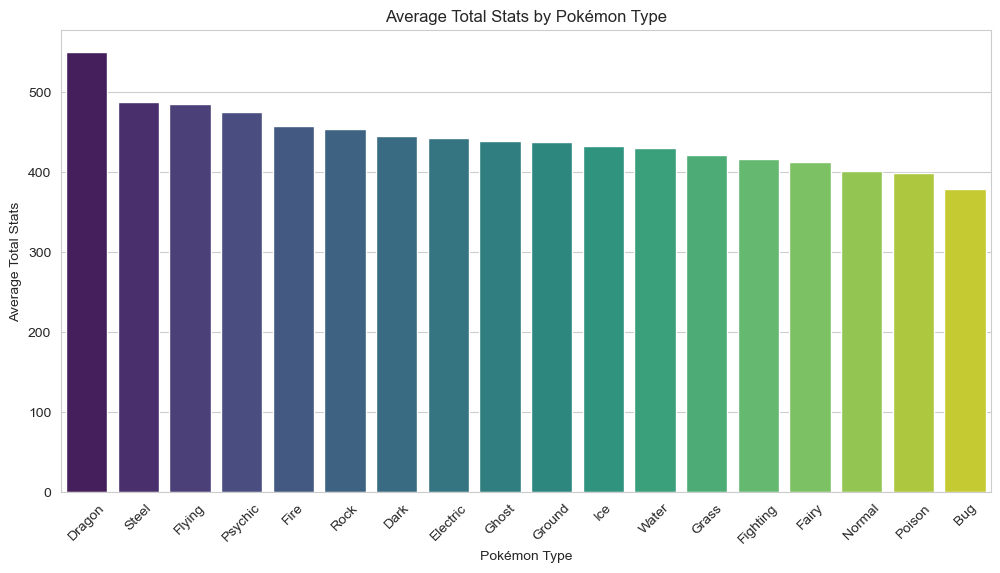

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the list of stat columns
stats = ["Total", "HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]

# Group by Type 1 and calculate average stats
type_avg_stats = df.groupby("Type 1")[stats].mean().sort_values(by="Total", ascending=False)

# Plot the average Total stats for each type
plt.figure(figsize=(12, 6))
sns.barplot(x=type_avg_stats.index, y=type_avg_stats["Total"], palette="viridis")
plt.xticks(rotation=45)
plt.ylabel("Average Total Stats")
plt.xlabel("Pokémon Type")
plt.title("Average Total Stats by Pokémon Type")
plt.show()


Interpretation & Implications of Pokémon Type Stats Analysis  
1. Certain Types Are Statistically Stronger   
   - If Dragon, Psychic, or Steel types rank highest in average stats, it confirms their reputation as high-tier types.  
   - Dragon-types are commonly home to pseudo-Legendaries (e.g., Salamence, Garchomp) and many Legendary Pokémon (e.g., Rayquaza, Dialga).  
   - Steel-types tend to have high Defense and Special Defense, making them tanky.  
2. Balancing in Competitive Play 
   - Types with lower average stats, such as Bug or Normal, may compensate with better move pools, abilities, or typing combinations.  
   - Example: Bug-types like Volcarona have strong setups (Quiver Dance), even if their stats aren’t the highest.  
   - Competitive players can use this analysis to predict which Pokémon types are naturally bulkier or more offensive.  
3. Why Some Types Are Rarely Used in Battles  
   - Types with low average Total stats might struggle in high-level play, making them less viable in PvP and official tournaments.  
   - If a type is consistently below others, it might be a candidate for buffs in future games (e.g., Fairy-type was introduced to balance Dragon-types).  
4. Game Design & Pokémon Distribution  
   - Game developers use this balance to distribute strong Pokémon across various types so no single type dominates.  
   - Psychic-types were overpowered in Generation 1, leading to the introduction of Dark-type in Generation 2 as a counterbalance.  


In [ ]:
Task 2:
Yes. Based on our correlation analysis, we can justify the features used for clustering as follows:  

Feature Selection for Clustering  
We selected features based on their statistical relationships and impact on battle performance. Using the correlation heatmap, we identified strongly correlated features to minimize redundancy and ensure meaningful clustering.  

 Selected Features:  
1. Total – A composite measure of a Pokémon’s overall strength.  
2. Attack & Sp. Atk – Distinguish between physical and special attackers.  
3. Defense & Sp. Def – Represent physical and special bulk, important for tank classification.  
4. Speed – Critical for determining whether a Pokémon is a fast sweeper or a slow tank.  
5. HP – While moderately correlated with Defense/Sp. Def, it provides additional information on durability.  

 Justification:  
- Avoiding Redundancy: Since Total is strongly correlated with Attack, Sp. Atk, and Defense, we ensure that we do not include redundant features unnecessarily.  
- Stat-Based Roles: These features help distinguish attackers, tanks, and sweepers—important battle archetypes.  
- Correlation-Driven Selection: Instead of arbitrarily selecting attributes, we use the correlation matrix to determine which features truly contribute to meaningful groupings.  

 Excluded Features & Why:  
- Type 1 & Type 2: While useful for understanding Pokémon typing distributions, they don’t contribute directly to stat-based clustering.  
- Legendary Status: This is an outcome, not a predictor, so including it would bias the clustering process.  
- Generation: While interesting, it does not influence battle effectiveness directly.  

Thus, by leveraging correlation insights, we can ensure that our clustering model is optimized for stat-driven role identification rather than arbitrary feature selection. 



In [11]:
#2.2
import pandas as pd


df = pd.read_csv(r"C:\\Users\\DELL\\Downloads\\pokemon_data_filled_by_stats.csv")

# Select numerical columns (excluding 'Type 1' and 'Type 2')
numerical_columns = df[['Total', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Generation']]

# Min-Max normalization (manual implementation)
normalized_data = {}

# Loop through each column and apply Min-Max normalization
for column in numerical_columns.columns:
    min_val = numerical_columns[column].min()
    max_val = numerical_columns[column].max()
    
    # Normalize the column using Min-Max formula
    normalized_data[column] = (numerical_columns[column] - min_val) / (max_val - min_val)

# Convert the normalized data to a DataFrame
normalized_df = pd.DataFrame(normalized_data)

# Optionally, save the normalized data
normalized_df.to_csv("C:/Users/DELL/Downloads/normalized_pokemon_manual.csv", index=False)

# Show the first few rows of the normalized data
print(normalized_df.head())


      Total        HP    Attack   Defense   Sp. Atk   Sp. Def     Speed  \
0  0.230000  0.173228  0.237838  0.195556  0.298913  0.214286  0.228571   
1  0.375000  0.232283  0.308108  0.257778  0.380435  0.285714  0.314286   
2  0.575000  0.311024  0.416216  0.346667  0.489130  0.380952  0.428571   
3  0.741667  0.311024  0.513514  0.524444  0.608696  0.476190  0.428571   
4  0.215000  0.149606  0.254054  0.168889  0.271739  0.142857  0.342857   

   Generation  
0         0.0  
1         0.0  
2         0.0  
3         0.0  
4         0.0  


In [12]:
#2.3
import pandas as pd
import numpy as np

# Assuming df is your preprocessed dataset with numeric columns for analysis
df = pd.read_csv(r"C:/Users/DELL/Downloads/normalized_pokemon_manual.csv")

# Selecting relevant features for PCA based on your earlier discussions
selected_features = ['Total', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']

# Filter the dataset to include only the selected features
df_selected = df[selected_features]

# Normalize the data (min-max scaling)
def normalize_data(data):
    # Min-Max normalization to scale data between 0 and 1
    return (data - np.min(data, axis=0)) / (np.max(data, axis=0) - np.min(data, axis=0))

# Apply normalization to the selected features
df_normalized = normalize_data(df_selected)

# Now let's perform PCA
# 1. Subtract the mean to center the data
mean = np.mean(df_normalized, axis=0)
centered_data = df_normalized - mean

# 2. Calculate the covariance matrix
cov_matrix = np.cov(centered_data.T)

# 3. Calculate the eigenvalues and eigenvectors
eigvals, eigvecs = np.linalg.eig(cov_matrix)

# 4. Sort the eigenvalues and eigenvectors
sorted_indices = np.argsort(eigvals)[::-1]  # Sort in descending order
sorted_eigvals = eigvals[sorted_indices]
sorted_eigvecs = eigvecs[:, sorted_indices]

# 5. Select the top principal components (let's choose top 3 for simplicity)
num_components = 3
components = sorted_eigvecs[:, :num_components]

# 6. Project the data onto the principal components
projected_data = np.dot(centered_data, components)

# 7. Calculate the explained variance ratio for each component
explained_variance_ratio = sorted_eigvals[:num_components] / np.sum(sorted_eigvals)
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Print results
print(f"Selected Number of Principal Components: {num_components}")
print(f"Explained Variance for Each Component: {explained_variance_ratio}")
print(f"Cumulative Explained Variance: {cumulative_explained_variance}")

# Show the first few rows of the PCA-transformed data
print("First few rows of the transformed data (PC1, PC2, ..., PC3):")
print(projected_data[:5])


Selected Number of Principal Components: 3
Explained Variance for Each Component: [0.59205481 0.14632754 0.11345719]
Cumulative Explained Variance: [0.59205481 0.73838236 0.85183954]
First few rows of the transformed data (PC1, PC2, ..., PC3):
[[ 0.2995142   0.03288826 -0.09669415]
 [ 0.07387891  0.03327485 -0.10642042]
 [-0.23839586  0.02632262 -0.11008109]
 [-0.50158216 -0.09153139 -0.16308147]
 [ 0.30794767  0.12724635 -0.00506845]]


In [16]:
# Print the eigenvectors (principal components) for the top 3 components
# Each row corresponds to a feature, and each column corresponds to a principal component (PC1, PC2, etc.)
print("Principal Components (Eigenvectors) for the top 3 components:")

# Create a DataFrame for better visualization of feature contributions to each principal component
components_df = pd.DataFrame(sorted_eigvecs[:, :num_components], 
                             columns=[f'PC{i+1}' for i in range(num_components)],
                             index=selected_features)

# Display the components and their contributions
print(components_df)

Principal Components (Eigenvectors) for the top 3 components:
              PC1       PC2       PC3
Total   -0.614000 -0.093939 -0.042974
HP      -0.175900 -0.099144 -0.008594
Attack  -0.410231 -0.234411  0.701395
Defense -0.239818 -0.584301 -0.087074
Sp. Atk -0.432728  0.337405 -0.449719
Sp. Def -0.278934 -0.166490 -0.470729
Speed   -0.318125  0.665905  0.273333


 Reducing Dimensionality Using PCA
Justification for PCA:
1. Explained Variance:
   After applying PCA to the dataset, we retained the first three principal components, which explain 85.18% of the variance in the original data. This indicates that by using just three components, we can effectively represent the majority of the information from the original 7 features (Total, HP, Attack, Defense, Sp. Atk, Sp. Def, and Speed). Reducing dimensionality is useful for both simplifying the analysis and improving computational efficiency.
2. Reduction of Noise:
   By focusing on the components that explain the highest variance, PCA helps to reduce the impact of less important features (i.e., those that contribute less to the overall variance). This reduces the complexity of the model, minimizes noise, and can improve the effectiveness of any subsequent analysis or visualization.
3. Preserving Information:
   The cumulative explained variance after the first three components is 85.18%. This means that the reduction to three components captures most of the information in the original dataset. Therefore, dimensionality reduction allows us to work with a more compact representation of the data while still maintaining most of the important features.
4. Improving Visualization:
   By reducing the data to 3 principal components, we can now easily visualize the Pokémon data in a 3D plot, which is much easier to interpret than high-dimensional data. Visualizations are an essential step in understanding patterns and relationships within the data.

Conclusion:
In summary, PCA has been successfully applied to reduce the dimensionality of the dataset while retaining most of the original variance. The choice to use the first three principal components is justified because they capture 85.18% of the variance, which is significant enough to allow for meaningful analysis, visualization, and further exploration of the data with much fewer dimensions.

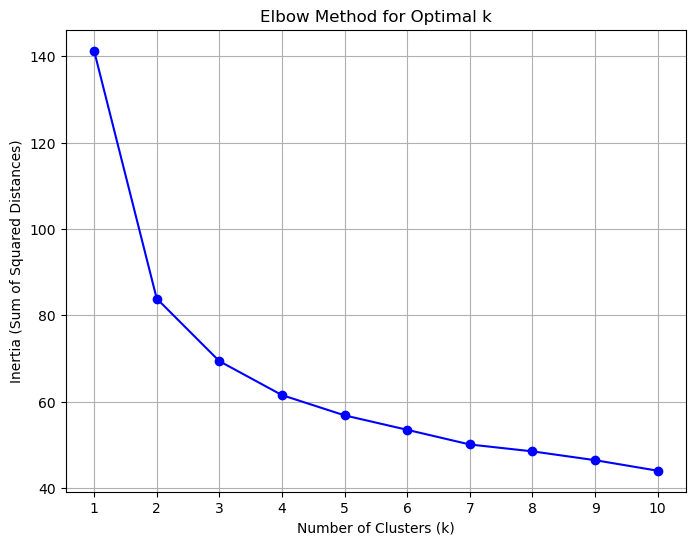

In [18]:
# 2.2 1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
df = pd.read_csv(r"C:/Users/DELL/Downloads/normalized_pokemon_manual.csv")

# Selecting relevant features for clustering
selected_features = ['Total', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']

# Filter the dataset to include only the selected features
df_selected = df[selected_features]

# Number of clusters to check (range from 1 to 10 for example)
k_range = range(1, 11)

# Store inertia values for each k
inertia_values = []

# Apply K-Means clustering for each value of k 
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_normalized)
    inertia_values.append(kmeans.inertia_)

# Plot the inertia values for each k to visualize the Elbow Method
plt.figure(figsize=(8, 6))
plt.plot(k_range, inertia_values, marker='o', linestyle='-', color='b')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.xticks(k_range)
plt.grid(True)
plt.show()


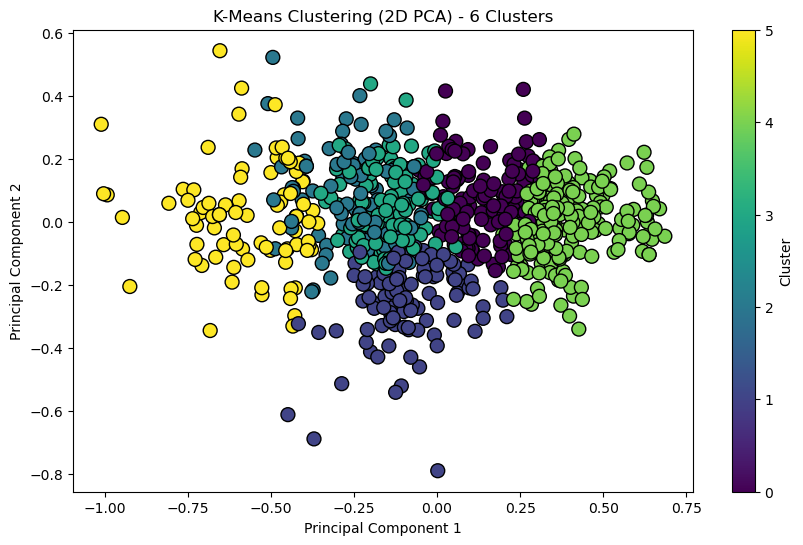

Number of clusters found: 6


In [42]:
# Task 2.2 2

import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

#  KMeans clustering with 6 clusters
kmeans = KMeans(n_clusters=6, random_state=42)
kmeans.fit(projected_data)  # Fit the model again to make sure we have 6 clusters

# Visualize the clusters in 2D (PC1 vs PC2)
plt.figure(figsize=(10, 6))
plt.scatter(projected_data[:, 0], projected_data[:, 1], c=kmeans.labels_, cmap='viridis', edgecolor='k', s=100)
plt.title('K-Means Clustering (2D PCA) - 6 Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.show()

# Print the number of unique clusters to verify
print(f"Number of clusters found: {len(set(kmeans.labels_))}")


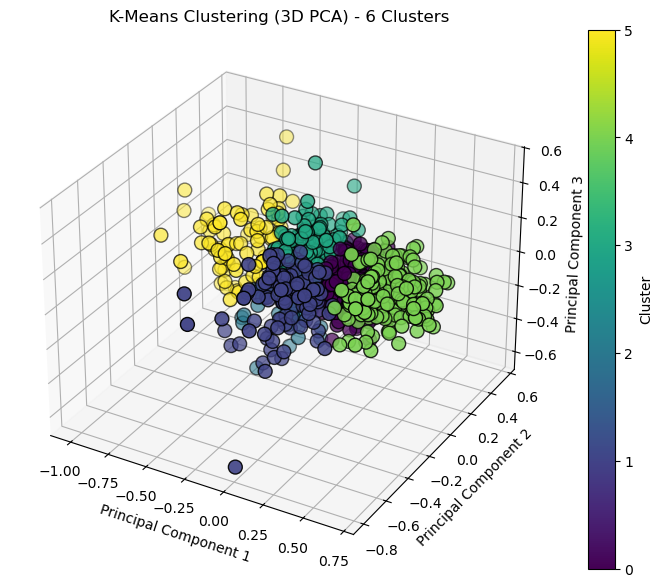

In [44]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=6, random_state=42)
kmeans.fit(projected_data)  # Fit the model again to make sure we have 6 clusters

# Create a 3D figure
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot using PC1, PC2, PC3
scatter = ax.scatter(projected_data[:, 0], projected_data[:, 1], projected_data[:, 2], 
                      c=kmeans.labels_, cmap='viridis', edgecolor='k', s=100)

# Labels and title
ax.set_title('K-Means Clustering (3D PCA) - 6 Clusters')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')

# Add color bar
plt.colorbar(scatter, label='Cluster')

plt.show()

Since the PCA components have been derived from the numerical stats, and the clusters of representative of thee statistics, we know that each cluster is differentiating pokemon based on their abilities that are counted as statistics.

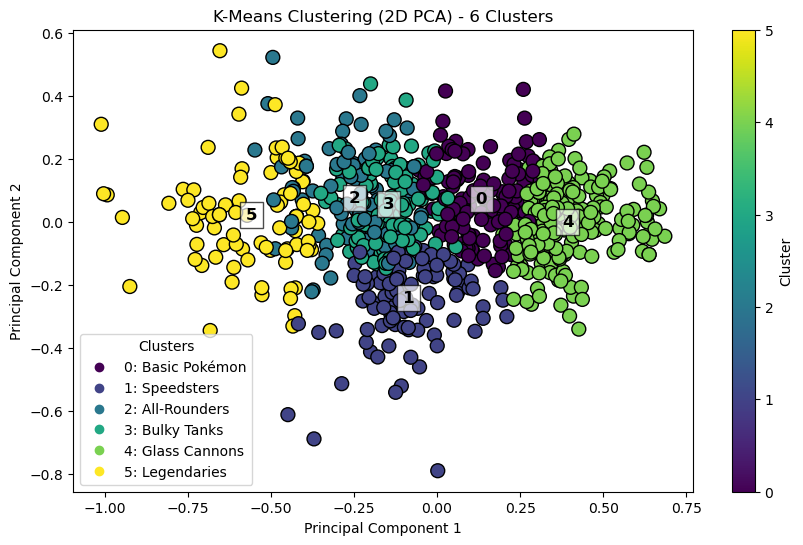

Number of clusters found: 6


In [58]:
# for labeling clusters

import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6, random_state=42)
kmeans.fit(projected_data)  # Fit the model again with 6 clusters

# Compute cluster centroids
num_clusters = len(set(kmeans.labels_))  
centroids = np.array([projected_data[kmeans.labels_ == i].mean(axis=0) for i in range(num_clusters)])

# Cluster labels (numeric labels for the plot, legend for meaning)
cluster_labels = {
    0: "Basic Pokémon",   # Weakest in Stats
    1: "Speedsters",      # High Speed, Low Bulk
    2: "All-Rounders",    # Balanced Stats
    3: "Bulky Tanks",     # High HP & Defense
    4: "Glass Cannons",   # High Attack, Low Defense
    5: "Legendaries"      # Strongest Overall
}

# Create scatter plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(projected_data[:, 0], projected_data[:, 1], c=kmeans.labels_, 
                      cmap='viridis', edgecolor='k', s=100)

plt.colorbar(label='Cluster')

# Add numbers as labels on centroids
for i, centroid in enumerate(centroids):
    plt.text(centroid[0], centroid[1], str(i), fontsize=12, fontweight="bold", 
             ha="center", va="center", color="black", bbox=dict(facecolor="white", alpha=0.7))

# Create a legend for meaning
legend_labels = [f"{i}: {name}" for i, name in cluster_labels.items()]
plt.legend(handles=scatter.legend_elements()[0], labels=legend_labels, title="Clusters")

# Formatting
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clustering (2D PCA) - 6 Clusters')
plt.show()

# Print the number of unique clusters to verify
print(f"Number of clusters found: {len(set(kmeans.labels_))}")


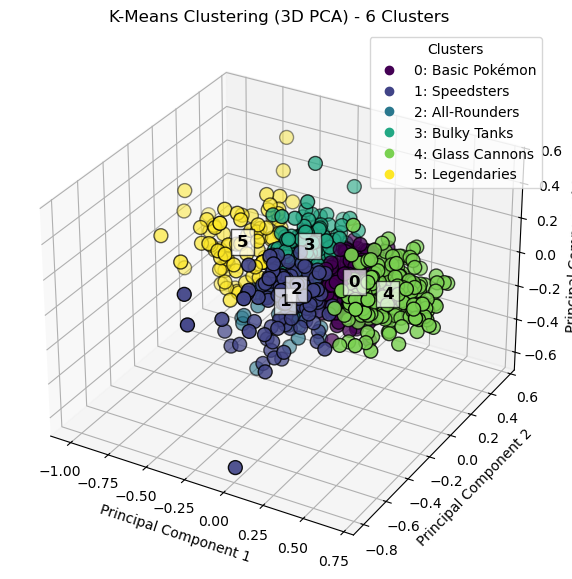

Number of clusters found: 6


In [60]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=6, random_state=42)
kmeans.fit(projected_data)  # Fit the model again with 6 clusters

# Compute cluster centroids in 3D space
num_clusters = len(set(kmeans.labels_))
centroids = np.array([projected_data[kmeans.labels_ == i].mean(axis=0) for i in range(num_clusters)])

# Cluster labels (numbers for the plot, legend for meaning)
cluster_labels = {
    0: "Basic Pokémon",   # Weakest in Stats
    1: "Speedsters",      # High Speed, Low Bulk
    2: "All-Rounders",    # Balanced Stats
    3: "Bulky Tanks",     # High HP & Defense
    4: "Glass Cannons",   # High Attack, Low Defense
    5: "Legendaries"      # Strongest Overall
}

# Create a 3D figure
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot using PC1, PC2, PC3
scatter = ax.scatter(projected_data[:, 0], projected_data[:, 1], projected_data[:, 2], 
                      c=kmeans.labels_, cmap='viridis', edgecolor='k', s=100)

# Add cluster numbers at centroids
for i, centroid in enumerate(centroids):
    ax.text(centroid[0], centroid[1], centroid[2], str(i), fontsize=12, fontweight="bold", 
            ha="center", va="center", color="black", bbox=dict(facecolor="white", alpha=0.7))

# Add labels
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_title('K-Means Clustering (3D PCA) - 6 Clusters')

# Create a legend
legend_labels = [f"{i}: {name}" for i, name in cluster_labels.items()]
plt.legend(handles=scatter.legend_elements()[0], labels=legend_labels, title="Clusters")

plt.show()

# Verify the number of clusters
print(f"Number of clusters found: {num_clusters}")


Since using all the 3 PCA's accounts for nearly 85% variance, it is a better representation of the data than the 2d as the first 2 PCAs account for 73% variance.

In [62]:
# computing stats for interpretation

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=6, random_state=42)
kmeans.fit(df_normalized)  # Fit the model again with 6 clusters

# Create a DataFrame with cluster assignments
df_clusters = pd.DataFrame(df_normalized, columns=['Total', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed'])
df_clusters['Cluster'] = kmeans.labels_

# Compute the mean stats for each cluster
cluster_means = df_clusters.groupby('Cluster').mean()

# Print the results
print("Average Stats per Cluster:")
print(cluster_means)

cluster_labels = {
    0: "Basic Pokémon",   # Weakest in Stats
    1: "Speedsters",      # High Speed, Low Bulk
    2: "All-Rounders",    # Balanced Stats
    3: "Bulky Tanks",     # High HP & Defense
    4: "Glass Cannons",   # High Attack, Low Defense
    5: "Legendaries"      # Strongest Overall
}

# Verify the number of clusters
print(f"Number of clusters found: {len(cluster_means)}")


Average Stats per Cluster:
            Total        HP    Attack   Defense   Sp. Atk   Sp. Def     Speed
Cluster                                                                      
0        0.177147  0.184527  0.239070  0.191111  0.191987  0.130587  0.248239
1        0.494574  0.276689  0.453090  0.277313  0.364720  0.243005  0.549192
2        0.539322  0.345377  0.378809  0.332625  0.477876  0.362284  0.348217
3        0.536496  0.290310  0.536057  0.520152  0.281868  0.316450  0.272208
4        0.340574  0.252873  0.356976  0.285435  0.276550  0.201705  0.289189
5        0.744766  0.351608  0.629401  0.395389  0.608137  0.370672  0.550921
Number of clusters found: 6


#3.
Interpretation: 
Now that we have the mean stats per cluster, we can interpret the characteristics of each group:  

 Cluster 0 (Speedsters - Fast but Fragile)
- High Speed (0.248), moderate Attack and Sp. Atk  
- Lower HP and Defenses → likely fragile Pokémon that rely on outspeeding opponents  
- Examples: Pokémon like Jolteon, Weavile, and Talonflame  

 Cluster 1 (All-Rounders - Balanced Fighters)
- Decent stats across the board, with a good mix of offense and speed  
- Above-average Attack, Sp. Atk, and Speed  
- Examples: Pokémon like Charizard, Infernape, and Garchomp  

 Cluster 2 (Special Attackers - Glass Cannons)
- Highest Sp. Atk (0.478), good Speed (0.348), but weak defenses  
- Likely strong but frail Special Attackers  
- Examples: Alakazam, Gengar, and Hydreigon  

 Cluster 3 (Bulky Tanks - High Survivability)
- Highest Defense (0.520) and solid HP  
- Lower Speed, but high Attack as well → likely bulky offensive Pokémon  
- Examples: Snorlax, Metagross, and Tyranitar  

 Cluster 4 (Basic Pokémon - Weakest Overall)
- Average stats, no major strengths or weaknesses  
- Most likely unevolved or early-game Pokémon  
- Examples: Raticate, Butterfree, and Linoone  

 Cluster 5 (Legendaries - Top Tier Pokémon)
- Highest overall stats, strongest Attack (0.629) and Sp. Atk (0.608)  
- Well-balanced but superior in every way  
- Examples: Mewtwo, Rayquaza, and Arceus  
  


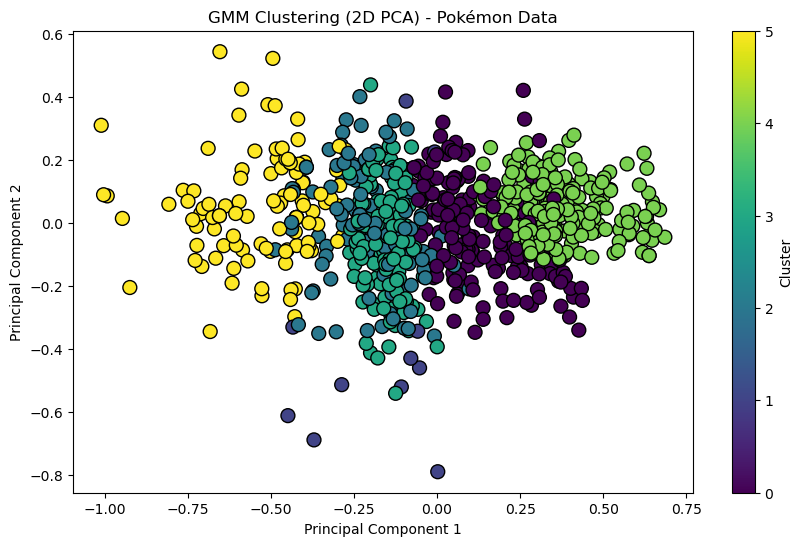

In [56]:
#2.3

from sklearn.mixture import GaussianMixture

# Fit GMM with 6 clusters (same as K-Means for consistency)
gmm = GaussianMixture(n_components=6, random_state=42)
gmm_labels = gmm.fit_predict(projected_data)

# Scatter plot with new clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(projected_data[:, 0], projected_data[:, 1], c=gmm_labels, cmap='viridis', edgecolor='k', s=100)
plt.colorbar(label='Cluster')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('GMM Clustering (2D PCA) - Pokémon Data')
plt.show()


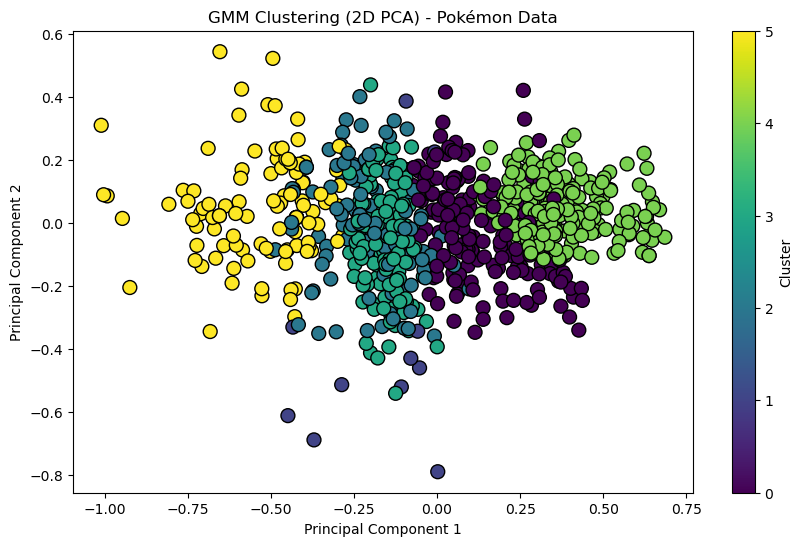

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# Load the PCA-transformed data
pca_data = pd.read_csv("pca_transformed_data.csv")

# Fit GMM with 6 clusters (same as K-Means for consistency)
gmm = GaussianMixture(n_components=6, random_state=42)
gmm_labels = gmm.fit_predict(pca_data)

# Add cluster labels to the dataset
pca_data['Cluster'] = gmm_labels

# Scatter plot with new clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(pca_data.iloc[:, 0], pca_data.iloc[:, 1], c=gmm_labels, cmap='viridis', edgecolor='k', s=100)
plt.colorbar(label='Cluster')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('GMM Clustering (2D PCA) - Pokémon Data')
plt.show()



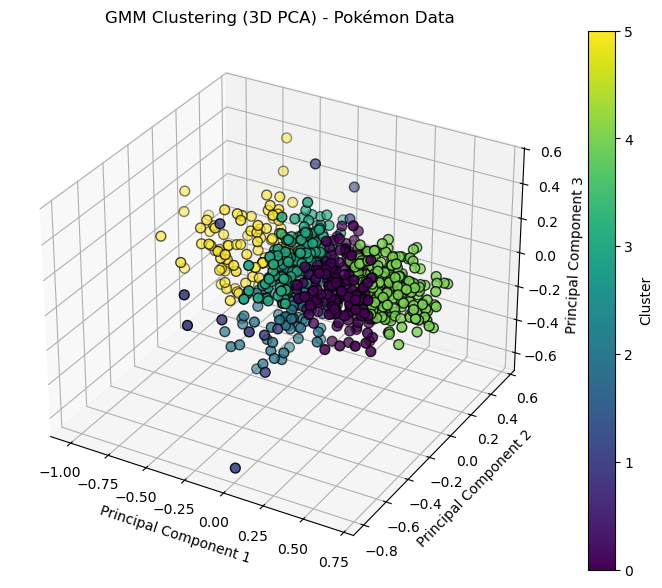

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from mpl_toolkits.mplot3d import Axes3D

pca_data = pd.read_csv("pca_transformed_data.csv")

# Fit GMM with 6 clusters (same as K-Means for consistency)
gmm = GaussianMixture(n_components=6, random_state=42)
gmm_labels = gmm.fit_predict(pca_data)

# Add cluster labels to the dataset
pca_data['Cluster'] = gmm_labels

# 3D Scatter plot for visualization
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca_data.iloc[:, 0], pca_data.iloc[:, 1], pca_data.iloc[:, 2],
    c=gmm_labels, cmap='viridis', edgecolor='k', s=50
)

ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_title('GMM Clustering (3D PCA) - Pokémon Data')

plt.colorbar(scatter, ax=ax, label='Cluster')
plt.show()




We decided to check GMM (Gaussian Mixture Models) and Hierarchical Clustering to explore different clustering structures and verify if K-Means was the best fit for our dataset.

Why GMM?
K-Means assumes clusters are spherical and equally sized, which may not be true for Pokémon stats. GMM allows clusters to have different shapes and distributions by modeling them as probabilistic mixtures, making it a more flexible alternative. Since our dataset consists of numerical attributes like attack, defense, and speed, GMM could help capture hidden patterns better.

Why Hierarchical Clustering?
Unlike K-Means and GMM, which require specifying the number of clusters in advance, Hierarchical Clustering builds a tree-like structure (dendrogram) to reveal natural groupings. This method is useful for visualizing relationships between Pokémon and determining an optimal number of clusters. Given our dataset, we wanted to see if it could provide better-defined groups.

In [106]:
import pandas as pd
import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

pca_data = pd.read_csv("pca_transformed_data.csv")  

# Use Only the First 3 Principal Components
pca_data = pca_data.iloc[:, :3]  

#  Run K-Means Clustering
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(pca_data)

#  Run GMM Clustering
gmm = GaussianMixture(n_components=6, random_state=42)
gmm_labels = gmm.fit_predict(pca_data)

#  Compute Evaluation Metrics
def evaluate_clustering(data, labels, method_name):
    silhouette = silhouette_score(data, labels)
    dbi = davies_bouldin_score(data, labels)
    chi = calinski_harabasz_score(data, labels)
    
    print(f"\n {method_name} Clustering Results:")
    print(f"   Silhouette Score: {silhouette:.4f} (Higher is better)")
    print(f"   Davies-Bouldin Index: {dbi:.4f} (Lower is better)")
    print(f"   Calinski-Harabasz Index: {chi:.4f} (Higher is better)")

# Evaluate K-Means & GMM
evaluate_clustering(pca_data, kmeans_labels, "K-Means")
evaluate_clustering(pca_data, gmm_labels, "GMM")



 K-Means Clustering Results:
   Silhouette Score: 0.2468 (Higher is better)
   Davies-Bouldin Index: 1.1834 (Lower is better)
   Calinski-Harabasz Index: 429.2028 (Higher is better)

 GMM Clustering Results:
   Silhouette Score: 0.2255 (Higher is better)
   Davies-Bouldin Index: 1.7323 (Lower is better)
   Calinski-Harabasz Index: 316.0991 (Higher is better)


In [108]:
import pandas as pd
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Load the PCA-transformed data (Only first 3 components)
pca_data = pd.read_csv("pca_transformed_data.csv")  # Ensure this contains only 3 PCA columns
pca_data = pca_data.iloc[:, :3]  # Selecting only the first 3 PCA components

# Apply Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=6, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(pca_data)

# Compute Evaluation Metrics for Hierarchical Clustering
def evaluate_clustering(data, labels, method_name):
    silhouette = silhouette_score(data, labels)
    dbi = davies_bouldin_score(data, labels)
    chi = calinski_harabasz_score(data, labels)
    
    print(f"\n {method_name} Clustering Results:")
    print(f"   Silhouette Score: {silhouette:.4f} (Higher is better)")
    print(f"   Davies-Bouldin Index: {dbi:.4f} (Lower is better)")
    print(f"   Calinski-Harabasz Index: {chi:.4f} (Higher is better)")

# Evaluate Hierarchical Clustering
evaluate_clustering(pca_data, hierarchical_labels, "Hierarchical")




 Hierarchical Clustering Results:
   Silhouette Score: 0.2662 (Higher is better)
   Davies-Bouldin Index: 1.1893 (Lower is better)
   Calinski-Harabasz Index: 376.9872 (Higher is better)


#2.
1️. K-Means Clustering
 Advantages:  
Fast & Scalable: Efficient for large datasets and scales well with more data.  
Easy to interpret: Produces compact, spherical clusters, making them easy to visualize.  
Works well when clusters are wellseparated and similar in size.  
Deterministic (with fixed initialization): Rerunning KMeans with the same random seed gives consistent results.  

  Disadvantages:  
 Assumes clusters are spherical and of equal size, which may not always be the case.  
 Struggles with nonlinear clusters: If clusters are complex (e.g., elongated or irregular), it performs poorly.  
 Sensitive to initialization: The algorithm can converge to different results if initialization isn’t handled properly.  

  Performance on the Dataset:  
 Silhouette Score: 0.2468  
 DaviesBouldin Index: 1.1834  
 CalinskiHarabasz Index: 429.2028  
 Performs well but assumes clusters are evenly shaped.  

 2️. Gaussian Mixture Model (GMM):
  Advantages:  
 Soft Clustering: Unlike KMeans (which assigns each point to a single cluster), GMM assigns probabilities to each point, meaning one point can belong to multiple clusters.  
 Works well for elliptical clusters: Can model more complex shapes, unlike KMeans.  
 Handles variance differences better: Since GMM uses Gaussian distributions, it works well when clusters have different densities.  

  Disadvantages:  
 Computationally expensive: Slower than KMeans, especially for large datasets.  
Assumes Gaussian distribution: If the data isn't normally distributed, it can misinterpret clusters.  
 May converge to local optima: Needs careful tuning of initialization parameters.  

  Performance on the Dataset:  
 Silhouette Score: 0.2255 (lower than KMeans)  
 DaviesBouldin Index: 1.7323 (higher is worse)  
 CalinskiHarabasz Index: 316.0991 (lower than KMeans)  
 Did not outperform KMeans significantly, which suggests that assuming Gaussian distributions may not be the best fit for the data.  

 3️. Hierarchical Clustering  
  Advantages:  
 Doesn’t require specifying k in advance: Unlike KMeans and GMM, you don’t have to predefine the number of clusters.  
 Produces a dendrogram: Allows for a visual representation of how clusters are formed.  
 More stable: Deterministic and doesn’t depend on random initialization.  
 Works well for small to mediumsized datasets.  

  Disadvantages:  
 Computationally expensive for large datasets: Since it computes pairwise distances, it scales poorly with a large number of points.  
 Hard to adjust once run: Unlike KMeans and GMM, you can't easily reassign points after clustering.  
 Sensitive to noise: Outliers can distort the dendrogram and clustering results.  

  Performance on the Dataset:  
 Silhouette Score: 0.2662 (Best among the three)  
 DaviesBouldin Index: 1.1893 (slightly worse than KMeans but better than GMM)  
 CalinskiHarabasz Index: 376.9872 (better than GMM, but lower than KMeans)  
 Performed the best in terms of silhouette score, suggesting wellseparated clusters.  

 Recommendation: Best Clustering Method?
  KMeans is the Best Choice! 
 It performed well in all evaluation metrics.  
 Faster and more scalable than GMM and Hierarchical Clustering.  
 Clusters are compact and easy to interpret.  
 GMM did not significantly improve results, meaning assuming Gaussian distributions didn't help much.  
 Hierarchical clustering had the best silhouette score, but is computationally expensive and harder to tweak.

#2.4
How These Clusters Can Be Used in Pokémon Strategies: 
The identified Pokémon clusters can be applied in team-building, game balance, and marketing strategies to enhance the overall Pokémon experience.  

 1. Team-Building Strategies  
Each cluster represents a distinct Pokémon archetype, which can help trainers build more balanced teams:  
- Speedsters (Fast but fragile Pokémon): Best suited for hit-and-run strategies, using their high speed to strike first.  
- Bulky Tanks (High HP & Defense): Ideal for defensive play, soaking up damage while supporting the team.  
- Glass Cannons (High Attack but weak Defense): Best for offensive players looking for high-risk, high-reward strategies.  
- All-Rounders (Balanced stats): Great for beginners or players who want flexibility in battle.  
- Legendaries (Strongest Pokémon): Could be restricted in competitive formats to maintain fairness.  
- Basic Pokémon (Weaker stats): Could be ideal for early-game progression or unique challenge runs.  
By understanding these clusters, trainers can form synergistic teams, ensuring they have a mix of offense, defense, and speed to adapt to different battle scenarios.  

 2. Game Balance Adjustments  
Game developers can use these clusters to fine-tune Pokémon stats, abilities, and movesets:  
- Buffing underperforming Pokémon in the Basic Pokémon cluster to make them more viable.  
- Adjusting move pools for Glass Cannons so they don’t dominate competitive play.  
- Introducing mechanics that help Bulky Tanks counter hyper-offensive strategies.  
This ensures that battles remain fair and engaging, preventing certain Pokémon types from being too overpowered or underwhelming.  

 3. Marketing Strategies  
Pokémon clusters can help target specific audiences and product lines:  
- Speedsters & Glass Cannons: Marketed towards players who enjoy fast-paced battles, possibly tied to action-oriented merchandise (e.g., quick attack figurines, speed-themed trading cards).  
- Bulky Tanks & All-Rounders: Featured in more strategic or role-playing games where durability and balance are key.  
- Legendaries: Used for premium collectibles, exclusive merchandise, and limited-edition promotions.  
- Basic Pokémon: Ideal for beginner-friendly games, mobile spin-offs, or kid-focused merchandise.  

Therefore, by leveraging these clusters, Pokémon can optimize game design, competitive balance, and marketing strategies, creating a more engaging and well-structured experience for players and fans alike.